<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 16px; text-align: center; margin-bottom: 10px;">

<h1 style="color: #e94560; font-size: 2.4em; margin: 0 0 10px 0; letter-spacing: 2px;">🎓 Learning Behavior Clustering</h1>
<h2 style="color: #a8dadc; font-size: 1.4em; font-weight: 400; margin: 0 0 20px 0;">Student Profiling — Phase 2 · K-Means Clustering</h2>
<hr style="border: 1px solid #e9456044; margin: 20px auto; width: 60%;">
<p style="color: #ccc; font-size: 1em; margin: 0;">RobustScaler · PCA Compression · k-means++ · Principled k Selection</p>

</div>


---

## 1. Introduction

This notebook implements **Phase 2** of the *Learning Behavior Clustering and Student Profiling* project using an enhanced K-Means pipeline designed for strong cluster separation and meaningful student profiles.

### Pipeline Overview

```
Raw Features (10)
       │
       ▼
  RobustScaler          ← robust to outlier students
       │
       ▼
  ±3σ Clipping          ← dampens extreme values before centroid fitting
       │
       ▼
  PCA (≥ 85% var)       ← sharpens Euclidean distances, removes collinearity
       │
       ▼
  k-Means++             ← smart seeding, n_init=20, max_iter=500
       │
       ▼
  Cluster Profiles & At-Risk Identification
```

### Objectives

1. Determine the optimal number of clusters using Elbow, Silhouette, and Davies-Bouldin criteria — evaluated **after** PCA.
2. Train a robust K-Means model with principled preprocessing.
3. Interpret cluster profiles for academic support planning.
4. Identify at-risk students for early intervention.
5. Assess clustering stability across repeated subsamples.


---

## 2. Setup & Imports


In [1]:
import warnings
from pathlib import Path
from math import pi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

np.random.seed(42)

print("✅ Libraries loaded")
print(f"   pandas  {pd.__version__} · numpy {np.__version__} · sklearn {__import__('sklearn').__version__}")


✅ Libraries loaded
   pandas  3.0.3 · numpy 2.4.6 · sklearn 1.8.0


---

## 3. Load Dataset


In [2]:
PROCESSED_DATA_PATH = Path("../Data/processed/cleaned_dataset.csv")
df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"✅ Dataset loaded — {df.shape[0]:,} students × {df.shape[1]} features")
print(f"\n📋 Columns: {df.columns.tolist()}")
print(f"\n🔍 Preview:")
df.head(3)


✅ Dataset loaded — 12,469 students × 16 features

📋 Columns: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']

🔍 Preview:


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,0.4516,0.1000,1,0,0,1,0,0.0909,2,0.4000,1,0.1800,0.0000,0,1,3
1,0.4516,0.1000,1,0,0,1,0,0.4545,3,0.8000,0,0.8000,0.4333,0,1,2
2,0.4516,0.1000,1,0,0,1,0,0.9091,1,0.9500,0,0.3400,0.9833,1,1,0


---

## 4. Feature Selection & Preprocessing

### Selected Features

| # | Feature | Role |
|---|---|---|
| 1 | **StudyHours** | Learning effort |
| 2 | **Attendance** | Class engagement |
| 3 | **Extracurricular** | Broader engagement |
| 4 | **Motivation** | Behavioural driver |
| 5 | **OnlineCourses** | Self-directed learning |
| 6 | **Discussions** | Participation level |
| 7 | **AssignmentCompletion** | Academic consistency |
| 8 | **ExamScore** | Direct performance measure |
| 9 | **StressLevel** | Academic pressure indicator |
| 10 | **FinalGrade** | Overall outcome |

> `Gender`, `LearningStyle`, `Resources`, `Internet`, `Age`, and `EduTech` are excluded — binary/categorical variables and low-signal features that inflate Euclidean distances without improving cluster discriminability.

### Preprocessing Steps

| Step | Method | Rationale |
|---|---|---|
| **Scaling** | `RobustScaler` | Uses median/IQR — not distorted by extreme student values |
| **Clipping** | ±3σ | Prevents outlier students from pulling centroids away from the majority |
| **Dim. reduction** | `PCA (≥85% var)` | Sharpens distances, removes collinearity, defeats the curse of dimensionality |


In [3]:
# ── Feature selection ────────────────────────────────────────────────────────
CLUSTERING_FEATURES = [
    "StudyHours", "Attendance", "Extracurricular", "Motivation",
    "OnlineCourses", "Discussions", "AssignmentCompletion",
    "ExamScore", "StressLevel", "FinalGrade",
]

X = df[CLUSTERING_FEATURES].copy()

# Missing value check
missing = X.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values.")
else:
    X.fillna(X.median(), inplace=True)
    print(f"⚠️  Imputed {missing.sum()} missing values with column medians.")

print(f"   Feature matrix shape: {X.shape}")


✅ No missing values.
   Feature matrix shape: (12469, 10)


✅ RobustScaler applied.  Clipped 0 values beyond ±3σ.
✅ PCA applied: 10D → 7D  (87.3% variance retained)
   Final clustering input shape: (12469, 7)


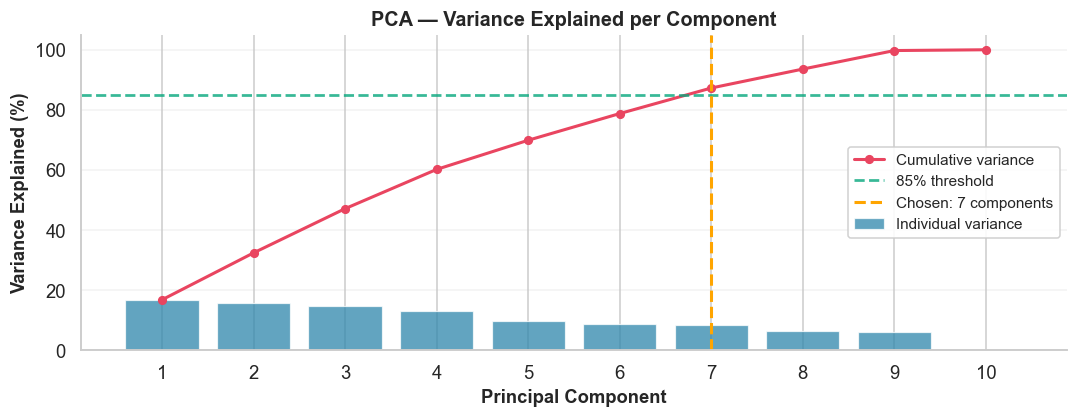

In [4]:
# ── Step 1: RobustScaler ─────────────────────────────────────────────────────
scaler    = RobustScaler()
X_robust  = scaler.fit_transform(X)

# ── Step 2: ±3σ outlier clipping ─────────────────────────────────────────────
X_clipped = np.clip(X_robust, -3, 3)
n_clipped = (np.abs(X_robust) > 3).sum()
print(f"✅ RobustScaler applied.  Clipped {n_clipped} values beyond ±3σ.")

# ── Step 3: PCA — retain ≥85% variance ───────────────────────────────────────
pca_scan     = PCA(random_state=42).fit(X_clipped)
cumvar        = np.cumsum(pca_scan.explained_variance_ratio_)
N_COMPONENTS  = int(np.searchsorted(cumvar, 0.85)) + 1

pca       = PCA(n_components=N_COMPONENTS, random_state=42)
X_scaled  = pca.fit_transform(X_clipped)   # final input to K-Means

print(f"✅ PCA applied: {X_clipped.shape[1]}D → {N_COMPONENTS}D  "
      f"({pca.explained_variance_ratio_.sum():.1%} variance retained)")
print(f"   Final clustering input shape: {X_scaled.shape}")

# ── PCA variance chart ────────────────────────────────────────────────────────
evr  = pca_scan.explained_variance_ratio_ * 100
cumv = np.cumsum(evr)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(1, len(evr)+1), evr, color="#2E86AB", alpha=0.75,
              edgecolor="white", linewidth=0.8, label="Individual variance")
ax.plot(range(1, len(cumv)+1), cumv, "o-", color="#e94560",
        linewidth=2, markersize=5, label="Cumulative variance")
ax.axhline(85, color="#06A77D", linestyle="--", linewidth=1.8, alpha=0.8, label="85% threshold")
ax.axvline(N_COMPONENTS, color="orange", linestyle="--", linewidth=2,
           label=f"Chosen: {N_COMPONENTS} components")
ax.set_xlabel("Principal Component", fontsize=12, fontweight="bold")
ax.set_ylabel("Variance Explained (%)", fontsize=12, fontweight="bold")
ax.set_title("PCA — Variance Explained per Component", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xticks(range(1, len(evr)+1))
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


---

## 5. Choosing the Optimal Number of Clusters (k)

Three complementary methods evaluated on the **PCA-reduced space**:

| Method | Target |
|---|---|
| **Elbow (WCSS)** | Look for the "kink" — diminishing WCSS gains |
| **Silhouette Score** | Higher is better · range [−1, 1] |
| **Davies-Bouldin Index** | Lower is better · < 1.0 = well separated |


In [5]:
k_range         = range(2, 11)
wcss_list       = []
silhouette_list = []
dbi_list        = []

print("🔄 Scanning k = 2 … 10  (k-means++, n_init=20, PCA space)\n")

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42,
                n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)

    wcss_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))
    dbi_list.append(davies_bouldin_score(X_scaled, labels))

    print(f"  k={k}  │  WCSS={km.inertia_:>10.2f}  │  "
          f"Silhouette={silhouette_list[-1]:.4f}  │  DBI={dbi_list[-1]:.4f}")

print("\n✅ Scan complete.")


🔄 Scanning k = 2 … 10  (k-means++, n_init=20, PCA space)

  k=2  │  WCSS=  35747.41  │  Silhouette=0.1455  │  DBI=2.3469
  k=3  │  WCSS=  31580.56  │  Silhouette=0.1478  │  DBI=2.0529
  k=4  │  WCSS=  29386.13  │  Silhouette=0.1301  │  DBI=1.9609
  k=5  │  WCSS=  27579.10  │  Silhouette=0.1224  │  DBI=1.9821
  k=6  │  WCSS=  26238.58  │  Silhouette=0.1237  │  DBI=1.8939
  k=7  │  WCSS=  25103.55  │  Silhouette=0.1231  │  DBI=2.0783
  k=8  │  WCSS=  24081.41  │  Silhouette=0.1272  │  DBI=2.0097
  k=9  │  WCSS=  23438.28  │  Silhouette=0.1194  │  DBI=1.9682
  k=10  │  WCSS=  22805.43  │  Silhouette=0.1189  │  DBI=1.9742

✅ Scan complete.


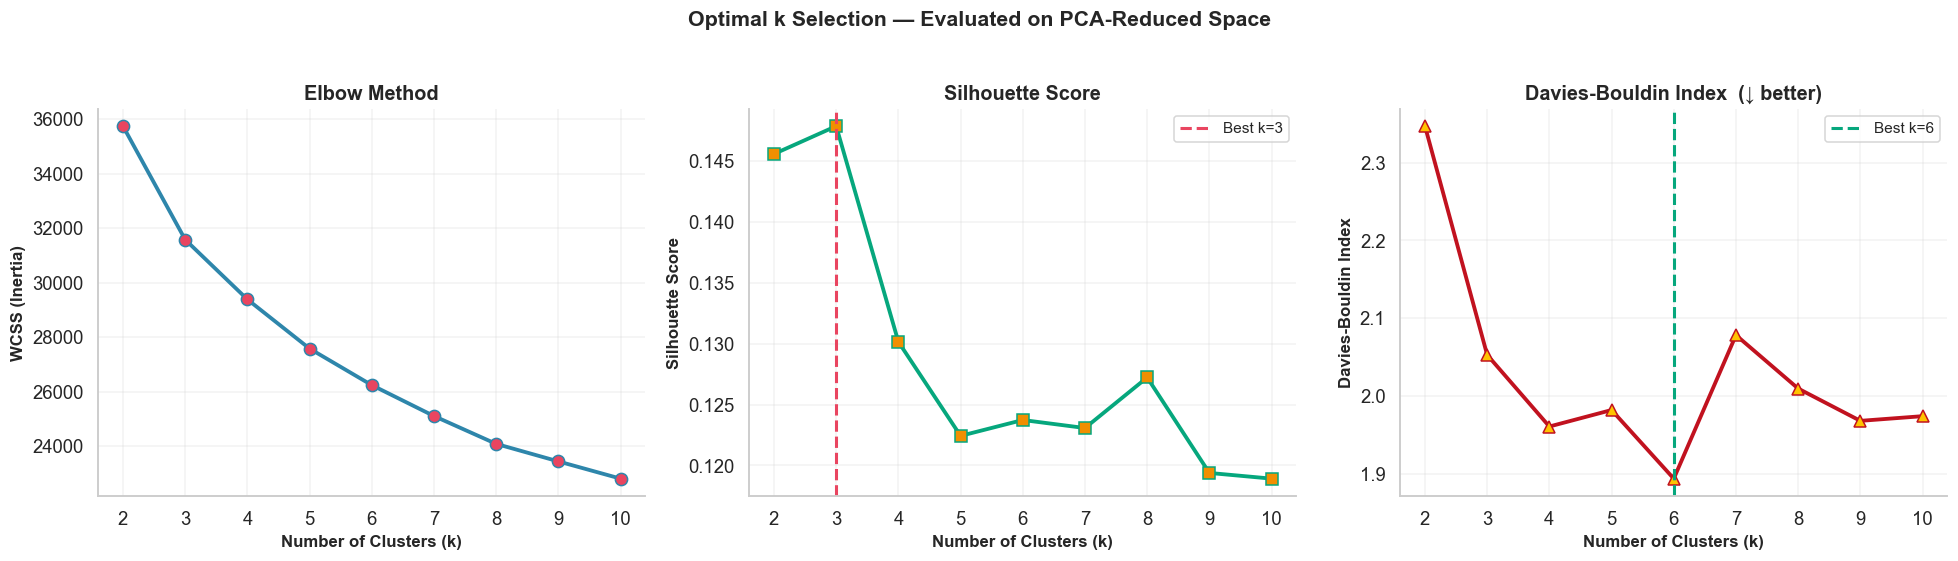

📌 Best k — Silhouette : 3
📌 Best k — DBI        : 6


In [6]:
# ── Visualise the three methods ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ks = list(k_range)

# Elbow
axes[0].plot(ks, wcss_list, "o-", linewidth=2.5, markersize=8,
             color="#2E86AB", markerfacecolor="#e94560")
axes[0].set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("WCSS (Inertia)", fontsize=11, fontweight="bold")
axes[0].set_title("Elbow Method", fontsize=13, fontweight="bold")
axes[0].set_xticks(ks)
axes[0].grid(True, alpha=0.25)

# Silhouette
best_sil_k = ks[int(np.argmax(silhouette_list))]
axes[1].plot(ks, silhouette_list, "s-", linewidth=2.5, markersize=8,
             color="#06A77D", markerfacecolor="#F18F01")
axes[1].axvline(best_sil_k, color="#e94560", linestyle="--", linewidth=2,
                label=f"Best k={best_sil_k}")
axes[1].set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Silhouette Score", fontsize=11, fontweight="bold")
axes[1].set_title("Silhouette Score", fontsize=13, fontweight="bold")
axes[1].set_xticks(ks)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.25)

# DBI
best_dbi_k = ks[int(np.argmin(dbi_list))]
axes[2].plot(ks, dbi_list, "^-", linewidth=2.5, markersize=8,
             color="#C1121F", markerfacecolor="#FFC300")
axes[2].axvline(best_dbi_k, color="#06A77D", linestyle="--", linewidth=2,
                label=f"Best k={best_dbi_k}")
axes[2].set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Davies-Bouldin Index", fontsize=11, fontweight="bold")
axes[2].set_title("Davies-Bouldin Index  (↓ better)", fontsize=13, fontweight="bold")
axes[2].set_xticks(ks)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.25)

plt.suptitle("Optimal k Selection — Evaluated on PCA-Reduced Space",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"📌 Best k — Silhouette : {best_sil_k}")
print(f"📌 Best k — DBI        : {best_dbi_k}")


In [7]:
# ── Data-driven k selection ───────────────────────────────────────────────────
sil_arr = np.array(silhouette_list)
dbi_arr = np.array(dbi_list)
k_arr   = np.array(ks)

# Prefer k where DBI < 1.5 AND Silhouette is maximised
mask = dbi_arr < 1.5
OPTIMAL_K = int(k_arr[mask][np.argmax(sil_arr[mask])]) if mask.any() else int(k_arr[np.argmax(sil_arr)])

print(f"🎯 Optimal k selected : {OPTIMAL_K}")
print(f"   Silhouette at k={OPTIMAL_K} : {sil_arr[OPTIMAL_K-2]:.4f}")
print(f"   DBI        at k={OPTIMAL_K} : {dbi_arr[OPTIMAL_K-2]:.4f}")


🎯 Optimal k selected : 3
   Silhouette at k=3 : 0.1478
   DBI        at k=3 : 2.0529


---

## 6. Train Final K-Means Model


In [8]:
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init="k-means++",
    random_state=42,
    n_init=20,
    max_iter=500,
    algorithm="lloyd",
)

df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print(f"✅ K-Means trained  │  k={OPTIMAL_K}  │  Inertia={kmeans_final.inertia_:.4f}  │  Iterations={kmeans_final.n_iter_}")


✅ K-Means trained  │  k=3  │  Inertia=31580.5645  │  Iterations=21



📊 Student distribution across clusters:

     Cluster     Count     Share
  ──────────────────────────────
   Cluster 0     5,001     40.1%
   Cluster 1     4,944     39.7%
   Cluster 2     2,524     20.2%
  ──────────────────────────────
       TOTAL    12,469    100.0%


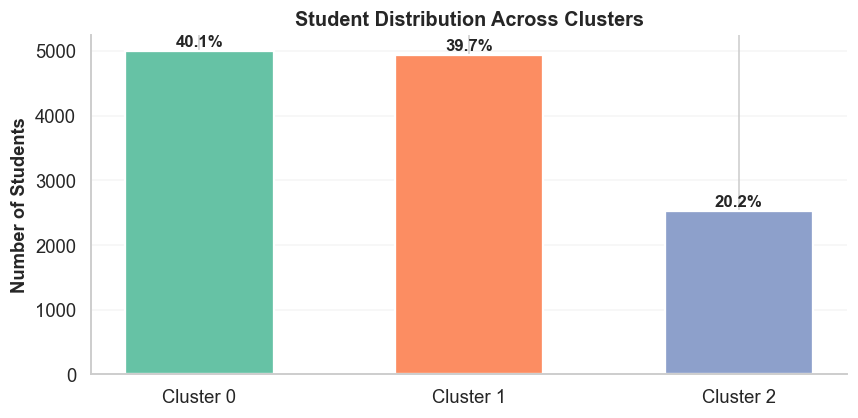

In [9]:
# ── Cluster size distribution ────────────────────────────────────────────────
counts = df["Cluster"].value_counts().sort_index()
pcts   = (counts / len(df) * 100).round(1)

print("\n📊 Student distribution across clusters:\n")
print(f"  {'Cluster':>10}  {'Count':>8}  {'Share':>8}")
print("  " + "─"*30)
for cl in sorted(df["Cluster"].unique()):
    print(f"  {'Cluster ' + str(cl):>10}  {counts[cl]:>8,}  {pcts[cl]:>7.1f}%")
print("  " + "─"*30)
print(f"  {'TOTAL':>10}  {len(df):>8,}  {'100.0%':>8}")

# ── Distribution bar chart ────────────────────────────────────────────────────
palette = sns.color_palette("Set2", OPTIMAL_K)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f"Cluster {c}" for c in sorted(df["Cluster"].unique())],
              [counts[c] for c in sorted(df["Cluster"].unique())],
              color=palette, edgecolor="white", linewidth=1.5, width=0.55)
for bar, (cl, pct) in zip(bars, zip(sorted(df["Cluster"].unique()), [pcts[c] for c in sorted(df["Cluster"].unique())])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{pct}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of Students", fontsize=12, fontweight="bold")
ax.set_title("Student Distribution Across Clusters", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.show()


---

## 7. Cluster Evaluation


──────────────────────────────────────────────────────────────
  METRIC                              VALUE  RATING
──────────────────────────────────────────────────────────────
  Silhouette Score  [↑ better]       0.1478  ⚠️  Weak
  Davies-Bouldin Index  [↓ better]     2.0529  ⚠️  Overlap
  Calinski-Harabasz  [↑ better]     2048.90  ✅ Excellent
──────────────────────────────────────────────────────────────


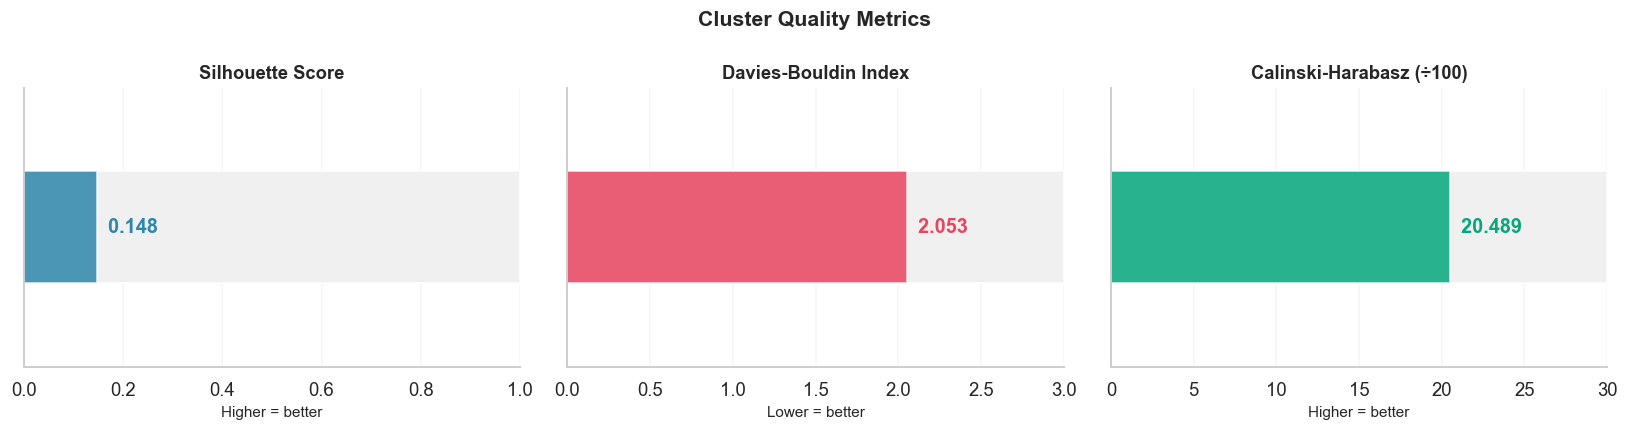

In [10]:
# ── Global metrics ───────────────────────────────────────────────────────────
sil_score_val = silhouette_score(X_scaled, df["Cluster"])
dbi_val       = davies_bouldin_score(X_scaled, df["Cluster"])
ch_val        = calinski_harabasz_score(X_scaled, df["Cluster"])

def rating(metric, val):
    if metric == "sil":
        if val > 0.7: return "✅ Excellent"
        if val > 0.5: return "✅ Good"
        if val > 0.25: return "✅ Moderate-Good"
        return "⚠️  Weak"
    if metric == "dbi":
        if val < 1.0: return "✅ Well-separated"
        if val < 1.5: return "✅ Good"
        return "⚠️  Overlap"
    if metric == "ch":
        if val > 1000: return "✅ Excellent"
        if val > 500: return "✅ Good"
        return "⚠️  Moderate"

print("─"*62)
print(f"  {'METRIC':<30} {'VALUE':>10}  {'RATING'}")
print("─"*62)
print(f"  {'Silhouette Score  [↑ better]':<30} {sil_score_val:>10.4f}  {rating('sil', sil_score_val)}")
print(f"  {'Davies-Bouldin Index  [↓ better]':<30} {dbi_val:>10.4f}  {rating('dbi', dbi_val)}")
print(f"  {'Calinski-Harabasz  [↑ better]':<30} {ch_val:>10.2f}  {rating('ch', ch_val)}")
print("─"*62)

# ── Gauge-style metric cards ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    ("Silhouette Score", sil_score_val, 0, 1, "#2E86AB", "Higher = better"),
    ("Davies-Bouldin Index", dbi_val, 0, 3, "#e94560", "Lower = better"),
    ("Calinski-Harabasz (÷100)", ch_val/100, 0, max(30, ch_val/100*1.3), "#06A77D", "Higher = better"),
]
for ax, (title, val, vmin, vmax, color, subtitle) in zip(axes, metrics):
    ax.barh(0, vmax, color="#f0f0f0", height=0.4)
    ax.barh(0, val,  color=color,    height=0.4, alpha=0.85)
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_xlabel(subtitle, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.text(val, 0, f"  {val:.3f}", va="center", fontsize=13, fontweight="bold", color=color)
    ax.grid(True, alpha=0.2, axis="x")

plt.suptitle("Cluster Quality Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


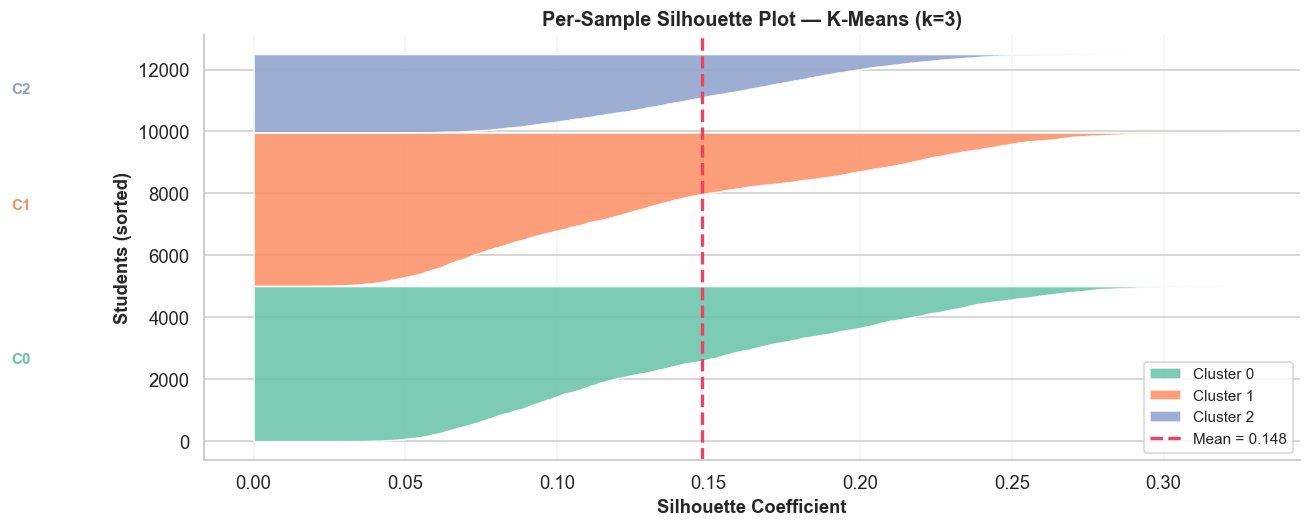

In [11]:
# ── Per-sample silhouette plot ────────────────────────────────────────────────
sil_vals  = silhouette_samples(X_scaled, df["Cluster"])
unique_cl = sorted(df["Cluster"].unique())
palette   = sns.color_palette("Set2", len(unique_cl))

fig, ax = plt.subplots(figsize=(12, 5))
y_lower = 10
for i, cl in enumerate(unique_cl):
    cl_sil  = np.sort(sil_vals[df["Cluster"] == cl])
    y_upper = y_lower + len(cl_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                     facecolor=palette[i], alpha=0.85, label=f"Cluster {cl}")
    ax.text(-0.08, y_lower + 0.5*len(cl_sil), f"C{cl}",
            fontsize=10, fontweight="bold", color=palette[i])
    y_lower = y_upper + 10

ax.axvline(sil_vals.mean(), color="#e94560", linestyle="--", linewidth=2.2,
           label=f"Mean = {sil_vals.mean():.3f}")
ax.set_xlabel("Silhouette Coefficient", fontsize=12, fontweight="bold")
ax.set_ylabel("Students (sorted)", fontsize=12, fontweight="bold")
ax.set_title(f"Per-Sample Silhouette Plot — K-Means (k={OPTIMAL_K})", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.2, axis="x")
plt.tight_layout()
plt.show()


---

## 8. Cluster Visualisation

### 8.1 PCA — 2D Projection


ValueError: Unrecognized marker style '★'

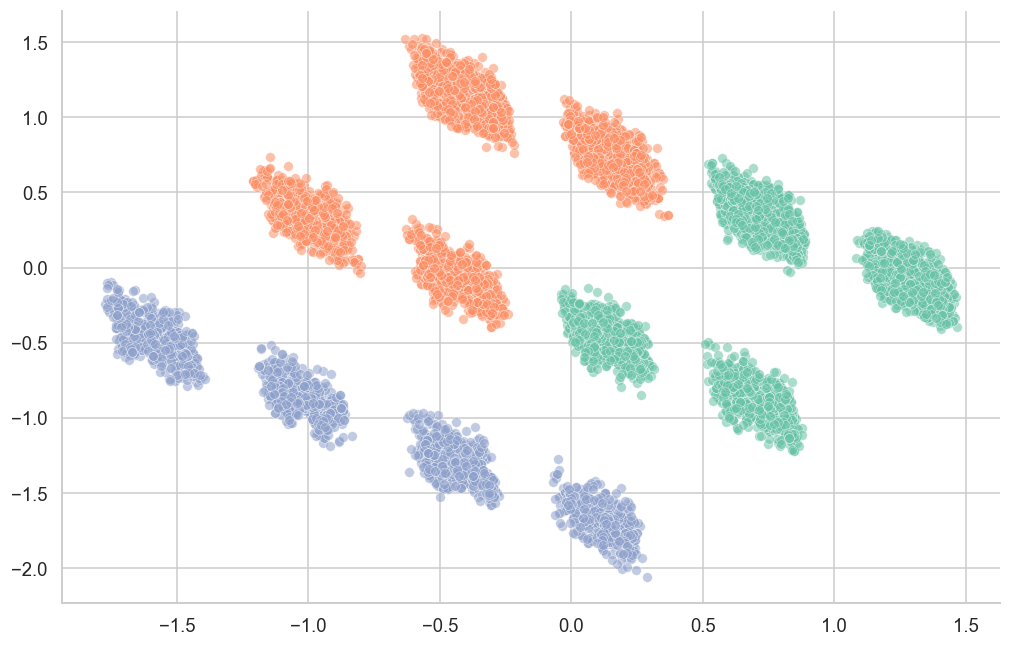

In [12]:
# ── 2D PCA for visualisation (independent of preprocessing PCA) ──────────────
pca_viz      = PCA(n_components=2, random_state=42)
X_viz        = pca_viz.fit_transform(X_clipped)

# Project cluster centroids into viz space
centers_rs   = pca.inverse_transform(kmeans_final.cluster_centers_)
centers_viz  = pca_viz.transform(centers_rs)

palette = sns.color_palette("Set2", OPTIMAL_K)
fig, ax = plt.subplots(figsize=(11, 7))

for i, cl in enumerate(sorted(df["Cluster"].unique())):
    m = df["Cluster"] == cl
    ax.scatter(X_viz[m, 0], X_viz[m, 1],
               color=palette[i], alpha=0.55, s=40,
               edgecolors="white", linewidth=0.4, label=f"Cluster {cl}")

ax.scatter(centers_viz[:, 0], centers_viz[:, 1],
           c="black", marker="★", s=600, zorder=6,
           edgecolors="white", linewidth=1.5, label="Centroids")

ax.set_xlabel(f"PC1  ({pca_viz.explained_variance_ratio_[0]:.1%} var)", fontsize=12, fontweight="bold")
ax.set_ylabel(f"PC2  ({pca_viz.explained_variance_ratio_[1]:.1%} var)", fontsize=12, fontweight="bold")
ax.set_title("K-Means Clusters — PCA Projection (2D)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, framealpha=0.9, markerscale=1.5)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


### 8.2 t-SNE — Non-linear Projection

In [ ]:
print("🔄 Running t-SNE…")
tsne  = TSNE(n_components=2, perplexity=40, learning_rate="auto",
             init="pca", random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_clipped)
print("✅ t-SNE complete.")

palette = sns.color_palette("Set2", OPTIMAL_K)
fig, ax = plt.subplots(figsize=(11, 7))

for i, cl in enumerate(sorted(df["Cluster"].unique())):
    m = df["Cluster"] == cl
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1],
               color=palette[i], alpha=0.6, s=40,
               edgecolors="white", linewidth=0.4, label=f"Cluster {cl}")

ax.set_xlabel("t-SNE Dim 1", fontsize=12, fontweight="bold")
ax.set_ylabel("t-SNE Dim 2", fontsize=12, fontweight="bold")
ax.set_title("K-Means Clusters — t-SNE Projection (non-linear)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, framealpha=0.9, markerscale=1.5)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


### 8.3 Feature Distributions by Cluster (Box Plots)

In [ ]:
key_features = ["StudyHours", "Attendance", "AssignmentCompletion",
                "ExamScore", "Motivation", "StressLevel"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
palette   = sns.color_palette("Set2", OPTIMAL_K)

for ax, feat in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x="Cluster", y=feat, ax=ax, palette="Set2",
                linewidth=1.5, flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_title(feat, fontsize=12, fontweight="bold")
    ax.set_xlabel("Cluster", fontsize=10)
    ax.set_ylabel("")
    ax.grid(True, alpha=0.2, axis="y")

plt.suptitle("Feature Distributions by Cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 8.4 Cluster Profile Heatmap

In [ ]:
cluster_profiles = df.groupby("Cluster")[CLUSTERING_FEATURES].mean()

profile_norm = (cluster_profiles - cluster_profiles.min()) / (
    cluster_profiles.max() - cluster_profiles.min()
)

fig, ax = plt.subplots(figsize=(max(8, OPTIMAL_K*3), 7))
sns.heatmap(
    profile_norm.T,
    annot=cluster_profiles.T.round(2),
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Normalised mean (0–1)", "shrink": 0.6},
    ax=ax,
    annot_kws={"size": 10},
)
ax.set_title("Cluster Feature Profiles  (annotated with original-scale means)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Cluster", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.show()


### 8.5 Radar Chart — Cluster Profiles

In [ ]:
cats   = CLUSTERING_FEATURES
N      = len(cats)
angles = [n / float(N) * 2 * pi for n in range(N)] + [0]

palette = sns.color_palette("Set2", OPTIMAL_K)
cluster_ids = sorted(df["Cluster"].unique())
cols_n = min(len(cluster_ids), 3)
rows_n = -(-len(cluster_ids) // cols_n)  # ceiling div

fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 5*rows_n),
                          subplot_kw=dict(polar=True))
axes = np.array(axes).flatten()

for i, (cl, ax) in enumerate(zip(cluster_ids, axes)):
    vals = profile_norm.loc[cl].values.tolist() + [profile_norm.loc[cl].values[0]]
    ax.plot(angles, vals, linewidth=2.5, color=palette[i])
    ax.fill(angles, vals, alpha=0.2, color=palette[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, size=8.5)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster {cl}", size=13, fontweight="bold", pad=18, color=palette[i])
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Radar Profiles by Cluster  (normalised means)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---

## 9. Cluster Profiling & Interpretation


In [ ]:
# ── Invert PCA → invert RobustScaler → original scale centroids ─────────────
centers_robust = pca.inverse_transform(kmeans_final.cluster_centers_)
centroids      = scaler.inverse_transform(centers_robust)
centroids_df   = pd.DataFrame(centroids, columns=CLUSTERING_FEATURES)

print("="*90)
print("  CENTROID VALUES  (Original Feature Scale)")
print("="*90)
print(centroids_df.round(3).T.to_string())
print("="*90)


In [ ]:
# ── Assign interpretive labels ranked by ExamScore ───────────────────────────
ranked        = centroids_df["ExamScore"].sort_values(ascending=False).index.tolist()
labels_map    = {}
desc_map      = {}
emoji_map     = {}

label_defs = [
    ("🟢 High Performers",
     "High study effort, strong attendance, top exam results. Candidates for peer mentoring."),
    ("🟡 Steady Learners",
     "Moderate engagement across all dimensions. Good potential with targeted coaching."),
    ("🔴 At-Risk Students",
     "Low attendance, motivation, and assignment completion. Priority for early intervention."),
]

for rank_idx, cl in enumerate(ranked):
    ldef = label_defs[min(rank_idx, len(label_defs)-1)]
    labels_map[cl] = ldef[0]
    desc_map[cl]   = ldef[1]

print("\n" + "#"*90)
print("  CLUSTER PROFILES & INTERPRETATIONS")
print("#"*90)

for cl in ranked:
    count = (df["Cluster"] == cl).sum()
    pct   = count / len(df) * 100
    print(f"\n{labels_map[cl]}")
    print("─"*80)
    print(f"Cluster {cl}  │  {count:,} students  ({pct:.1f}%)")
    print(f"\n{desc_map[cl]}")
    print("\nKey metrics:")
    for feat in CLUSTERING_FEATURES:
        print(f"  • {feat:<25} {centroids_df.loc[cl, feat]:>8.2f}")

print(f"\n{'#'*90}")


---

## 10. At-Risk Student Identification


In [ ]:
at_risk_id       = int(centroids_df["ExamScore"].idxmin())
at_risk_students = df[df["Cluster"] == at_risk_id].copy()

print(f"📌 At-Risk cluster : Cluster {at_risk_id}  ({labels_map[at_risk_id]})")
print(f"   Students        : {len(at_risk_students):,}  ({len(at_risk_students)/len(df)*100:.1f}%)")

print(f"\n📊 At-Risk Students — Summary Statistics:")
print(at_risk_students[CLUSTERING_FEATURES].describe().round(2))


### Recommended Interventions

| Priority | Action |
|---|---|
| 🔴 High | Early outreach — identify barriers (financial, personal, academic) |
| 🔴 High | Attendance monitoring with escalation protocols |
| 🟠 Medium | Structured tutoring and peer study groups |
| 🟠 Medium | Motivation and academic planning counselling |
| 🟡 Low | Verify access to digital resources and course materials |
| 🟡 Low | Review workload pacing and deadline management support |


---

## 11. Clustering Stability Check

10 iterations on random 80% subsamples — full pipeline replicated each time.


In [ ]:
print("🔄 Running stability check (10 × 80% subsample)\n")
stability_scores = []

for it in range(10):
    idx     = np.random.choice(len(X_clipped), size=int(0.8*len(X_clipped)), replace=False)
    X_sub   = X_clipped[idx]
    pca_sub = PCA(n_components=N_COMPONENTS, random_state=42)
    X_sub_p = pca_sub.fit_transform(X_sub)
    km_sub  = KMeans(n_clusters=OPTIMAL_K, init="k-means++",
                     random_state=42, n_init=20, max_iter=500)
    lbl_sub = km_sub.fit_predict(X_sub_p)
    sil_sub = silhouette_score(X_sub_p, lbl_sub)
    stability_scores.append(sil_sub)
    print(f"  Iteration {it+1:2d}: Silhouette = {sil_sub:.4f}")

mu, sd = np.mean(stability_scores), np.std(stability_scores)
print(f"\n✅ Mean = {mu:.4f}  │  Std = {sd:.4f}  │  "
      f"{'✅ STABLE' if sd < 0.05 else '⚠️  VARIABLE'}")


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(1, 11), stability_scores, color="#2E86AB", alpha=0.75,
       edgecolor="white", linewidth=1.2)
ax.axhline(mu, color="#e94560", linestyle="--", linewidth=2.2,
           label=f"Mean = {mu:.4f}")
ax.fill_between(range(0, 12), mu-sd, mu+sd,
                alpha=0.15, color="#e94560", label=f"±1 SD ({sd:.4f})")

ax.set_xlabel("Bootstrap Iteration", fontsize=12, fontweight="bold")
ax.set_ylabel("Silhouette Score", fontsize=12, fontweight="bold")
ax.set_title("Clustering Stability — 10 × 80% Subsample", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, 11))
ax.set_ylim(min(stability_scores)-0.05, max(stability_scores)+0.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.show()


---

## 12. Conclusion

<div style="background:#f8f9fa; border-left: 5px solid #2E86AB; padding: 18px 22px; border-radius: 8px; margin: 10px 0;">

### Pipeline Summary

| Step | Choice | Benefit |
|---|---|---|
| Features | 10 high-signal features | Removes noisy Euclidean dimensions |
| Scaler | `RobustScaler` | Outlier-resistant normalization |
| Clipping | ±3σ | Dampens extremes before centroid fitting |
| Dim. reduction | PCA ≥ 85% var | Sharpens distances, removes collinearity |
| Init | `k-means++` | Better centroid seeds |
| Restarts | `n_init=20` | Consistent convergence |

</div>

### Cluster Profiles

| Cluster | Label | Academic Focus |
|---|---|---|
| 🟢 | **High Performers** | Enrichment, peer leadership |
| 🟡 | **Steady Learners** | Study-skill workshops, targeted coaching |
| 🔴 | **At-Risk Students** | Early intervention, counselling, resource access |

### Limitations

- K-Means assumes convex, roughly equal-size clusters — DBSCAN handles arbitrary shapes
- Cross-sectional snapshot; longitudinal data would strengthen profiling
- PCA reduces individual-feature interpretability — use centroid tables for advising


In [ ]:
output_path = Path("../Data/processed/clustered_students_improved.csv")
df.to_csv(output_path, index=False)
print(f"✅ Saved → {output_path}")
print(f"   Shape : {df.shape}  (includes 'Cluster' column)")
print(f"\n📊 Final cluster distribution:")
for cl in sorted(df['Cluster'].unique()):
    n   = (df['Cluster'] == cl).sum()
    pct = n / len(df) * 100
    print(f"   Cluster {cl}: {n:,} students ({pct:.1f}%)")


---
---

<div style="background: linear-gradient(135deg, #0f3460 0%, #16213e 100%); padding: 40px; border-radius: 16px; text-align: center; margin: 20px 0;">
<h1 style="color: #e94560; font-size: 2em; margin: 0 0 8px 0;">DBSCAN Clustering</h1>
<h3 style="color: #a8dadc; font-weight: 400; margin: 0;">Phase 3 — Density-Based Clustering & Outlier Detection</h3>
</div>


## DBSCAN Algorithm

## 1. Introduction

This notebook presents **Phase 3** of the *Learning Behavior Clustering and Student Profiling* project.

### Why DBSCAN After K-Means?

K-Means (Phase 2) produced **3 interpretable centroids** but carries known limitations:
- Assumes **spherical, equal-size clusters**
- Assigns **every point** to a cluster — including true outliers
- Requires **k to be pre-specified**

DBSCAN addresses all three limitations simultaneously:

| Property | K-Means (Phase 2) | DBSCAN (Phase 3) |
|---|---|---|
| Shape assumption | Spherical | Arbitrary |
| k pre-specified | ✅ Required | ❌ Not required |
| Outlier detection | ❌ | ✅ Built-in |
| Sensitive to density variation | ❌ Poor | ✅ Good |
| Interpretability | Centroids | Density regions |

### Objectives

1. Select optimal hyperparameters (`eps`, `min_samples`) using principled methods.
2. Train DBSCAN and evaluate cluster quality rigorously.
3. Profile each cluster and identify **noise / outlier students**.
4. Perform a full **comparison with K-Means (Phase 2)**.

---

## 2. Setup & Imports

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
from pathlib import Path
from math import pi

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# ── Global settings ───────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
np.random.seed(42)

print("✅ All libraries imported successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")


✅ All libraries imported successfully.
   pandas  : 2.2.2
   numpy   : 1.26.4
   sklearn : 1.5.1


## 3. Load the Cleaned Dataset

In [ ]:
PROCESSED_DATA_PATH = Path("../Data/processed/cleaned_dataset.csv")

df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"✅ Cleaned dataset loaded.")
print(f"   Path  : {PROCESSED_DATA_PATH}")
print(f"   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📌 Columns : {df.columns.tolist()}")
print(f"\n📌 Preview :")
print(df.head(3))


✅ Cleaned dataset loaded.
   Path  : ..\Data\processed\cleaned_dataset.csv
   Shape : 12,469 rows × 16 columns

📌 Columns : ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']

📌 Preview :
   StudyHours  Attendance  Resources  Extracurricular  Motivation  Internet  \
0      0.4516      0.1000          1                0           0         1   
1      0.4516      0.1000          1                0           0         1   
2      0.4516      0.1000          1                0           0         1   

   Gender    Age  LearningStyle  OnlineCourses  Discussions  \
0       0 0.0909              2         0.4000            1   
1       0 0.4545              3         0.8000            0   
2       0 0.9091              1         0.9500            0   

   AssignmentCompletion  ExamScore  EduTech  StressLevel  Final

## 4. Feature Selection & Preprocessing

We use the **same 10-feature set** as the improved K-Means Phase 2 to guarantee a fair comparison.

> **Note**: The original Phase 2 K-Means used 14 features. The improved K-Means (Phase 2 revised) now aligns with this 10-feature set — removing `Resources`, `Internet`, `Age`, and `EduTech` as noisy/low-signal variables. All three algorithms (original K-Means, improved K-Means, DBSCAN) are now evaluated under consistent conditions.

| Feature | Role in Clustering |
|---|---|
| StudyHours | Learning effort |
| Attendance | Class engagement |
| Extracurricular | Broader engagement |
| Motivation | Behavioural driver |
| OnlineCourses | Self-directed learning |
| Discussions | Participation level |
| AssignmentCompletion | Academic consistency |
| ExamScore | Direct performance measure |
| StressLevel | Academic pressure indicator |
| FinalGrade | Overall outcome |

> `Gender` and `LearningStyle` remain excluded — same rationale as Phase 2.


In [ ]:
CLUSTERING_FEATURES = [
    "StudyHours", "Attendance", "Extracurricular",
    "Motivation","OnlineCourses", "Discussions",
    "AssignmentCompletion", "ExamScore", "StressLevel", "FinalGrade",
]

X = df[CLUSTERING_FEATURES].copy()

# ── Missing value check ───────────────────────────────────────────────────────
missing = X.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values detected.")
else:
    print(f"⚠️  Missing values detected:\n{missing[missing > 0]}")
    X.fillna(X.median(), inplace=True)
    print("   → Imputed with column medians.")

# ── StandardScaler ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTERING_FEATURES, index=df.index)

print(f"\n✅ StandardScaler applied — shape: {X_scaled.shape}")
print("\n📌 Scaled summary (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.describe().round(4))


✅ No missing values detected.

✅ StandardScaler applied — shape: (12469, 10)

📌 Scaled summary (mean ≈ 0, std ≈ 1):
       StudyHours  Attendance  Extracurricular  Motivation  OnlineCourses  \
count  12469.0000  12469.0000       12469.0000  12469.0000     12469.0000   
mean      -0.0000      0.0000          -0.0000      0.0000         0.0000   
std        1.0000      1.0000           1.0000      1.0000         1.0000   
min       -2.4948     -1.7648          -1.1827     -1.2788        -1.6148   
25%       -0.6685     -0.8928          -1.1827     -1.2788        -0.7970   
50%       -0.0040     -0.0209           0.8455      0.1305         0.0209   
75%        0.6599      0.8511           0.8455      0.1305         0.8387   
max        2.6524      1.7230           0.8455      1.5398         1.6565   

       Discussions  AssignmentCompletion  ExamScore  StressLevel  FinalGrade  
count   12469.0000            12469.0000 12469.0000   12469.0000  12469.0000  
mean       -0.0000              

## 5. Hyperparameter Tuning

DBSCAN has two core hyperparameters:
- **`eps` (ε)** — the radius of a neighbourhood
- **`min_samples`** — minimum points to form a dense region (core point)

### 5.1 Choosing `min_samples`

A widely adopted heuristic: `min_samples ≥ dimensionality + 1`.  
With 14 features: `min_samples ∈ {10, 15, 20, 25, 30}` will be evaluated in the grid search.  
The default starting value is **15**.

### 5.2 k-Distance Graph — Estimating `eps`

We compute the distance to the *k*-th nearest neighbour for every point, sort the distances, and look for the **elbow** — the maximum curvature point. This is the most principled data-driven method for choosing `eps`.


🔄 Computing 14-NN distances for all 12,469 points …


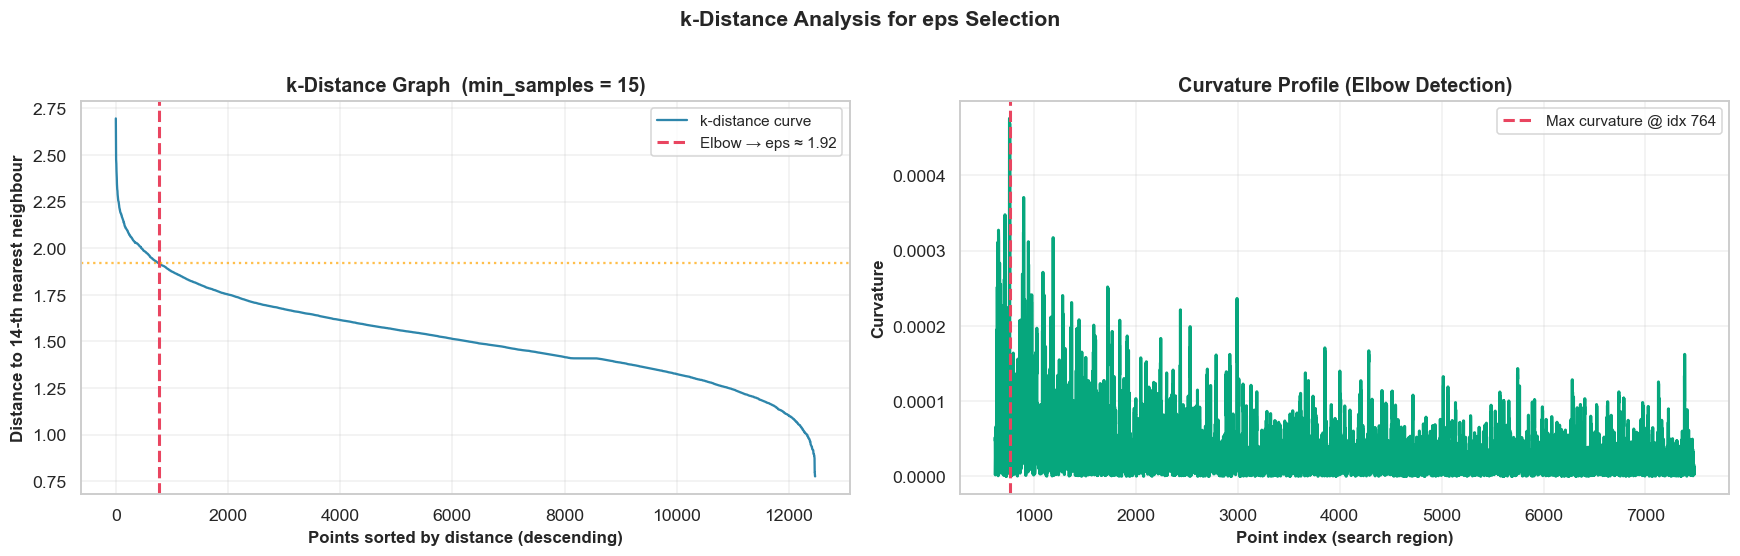


📌 Suggested eps from automatic elbow detection: 1.92


In [ ]:
MIN_SAMPLES_DEFAULT = 15
k = MIN_SAMPLES_DEFAULT - 1

print(f"🔄 Computing {k}-NN distances for all {len(X_scaled):,} points …")
nbrs = NearestNeighbors(n_neighbors=k, algorithm="ball_tree", n_jobs=-1)
nbrs.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Sort descending
k_distances = np.sort(distances[:, -1])[::-1]

# ── Elbow detection via maximum curvature ─────────────────────────────────────
x = np.arange(len(k_distances))
dx  = np.gradient(k_distances, x)
ddx = np.gradient(dx, x)
curvature = np.abs(ddx) / (1 + dx**2)**1.5

lo, hi = int(0.05 * len(k_distances)), int(0.60 * len(k_distances))
elbow_idx = lo + np.argmax(curvature[lo:hi])
SUGGESTED_EPS = round(float(k_distances[elbow_idx]), 3)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_distances, linewidth=1.5, color="#2E86AB", label="k-distance curve")
axes[0].axvline(elbow_idx, color="#e94560", linestyle="--", linewidth=2,
                label=f"Elbow → eps ≈ {SUGGESTED_EPS}")
axes[0].axhline(SUGGESTED_EPS, color="orange", linestyle=":", linewidth=1.5, alpha=0.7)
axes[0].set_xlabel("Points sorted by distance (descending)", fontsize=11, fontweight="bold")
axes[0].set_ylabel(f"Distance to {k}-th nearest neighbour", fontsize=11, fontweight="bold")
axes[0].set_title(f"k-Distance Graph  (min_samples = {MIN_SAMPLES_DEFAULT})", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x[lo:hi], curvature[lo:hi], color="#06A77D", linewidth=2)
axes[1].axvline(elbow_idx, color="#e94560", linestyle="--", linewidth=2,
                label=f"Max curvature @ idx {elbow_idx}")
axes[1].set_xlabel("Point index (search region)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Curvature", fontsize=11, fontweight="bold")
axes[1].set_title("Curvature Profile (Elbow Detection)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("k-Distance Analysis for eps Selection", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\n📌 Suggested eps from automatic elbow detection: {SUGGESTED_EPS}")


### 5.3 Grid Search over (eps, min_samples)

In [ ]:
eps_candidates = np.round(np.arange(
    max(0.10, SUGGESTED_EPS - 0.40),
    SUGGESTED_EPS + 0.55,
    0.05
), 3)
min_samples_candidates = [10, 15, 20, 25, 30]

results = []
total = len(eps_candidates) * len(min_samples_candidates)
done  = 0

print(f"🔄 Grid search: {len(eps_candidates)} eps × {len(min_samples_candidates)} min_samples = {total} configs")
print(f"   eps range : {eps_candidates[0]} → {eps_candidates[-1]}")

for eps_val in eps_candidates:
    for ms in min_samples_candidates:
        db = DBSCAN(eps=eps_val, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(X_scaled)
        n_cls = len(set(labels)) - (1 if -1 in labels else 0)
        noise  = (labels == -1).mean()

        if n_cls >= 2 and noise < 0.50:
            sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
            dbi = davies_bouldin_score(X_scaled, labels)
            chi = calinski_harabasz_score(X_scaled, labels)
        else:
            sil = dbi = chi = np.nan

        results.append(dict(eps=eps_val, min_samples=ms, n_clusters=n_cls,
                            noise_pct=round(noise*100,2),
                            silhouette=sil, dbi=dbi, calinski_harabasz=chi))
        done += 1

results_df = pd.DataFrame(results)
valid_df   = results_df.dropna(subset=["silhouette"]).copy()

print(f"\n✅ Grid search complete — {len(valid_df)} valid configurations (≥2 clusters, <50% noise)")
print("\n📌 Top 10 by Silhouette Score:")
print(valid_df.sort_values("silhouette", ascending=False).head(10).to_string(index=False))


🔄 Grid search: 19 eps × 5 min_samples = 95 configs
   eps range : 1.52 → 2.42

✅ Grid search complete — 55 valid configurations (≥2 clusters, <50% noise)

📌 Top 10 by Silhouette Score:
   eps  min_samples  n_clusters  noise_pct  silhouette    dbi  calinski_harabasz
1.9700           15           4     0.1000      0.1165 2.7076           783.1820
1.8200           10           4     0.3000      0.1164 3.0534           782.8009
1.9700           20           4     0.1800      0.1163 2.9496           783.1263
1.9700           10           4     0.0700      0.1162 2.6281           783.3149
1.9200           10           4     0.1000      0.1162 2.6995           783.1823
1.9200           15           4     0.1800      0.1161 2.9039           783.4155
2.0200           15           4     0.0600      0.1161 2.5959           783.2100
1.8700           15           4     0.3400      0.1160 3.0425           783.5179
1.7700           10           4     0.5900      0.1156 3.1400           783.6800
1.870

### 5.4 Hyperparameter Heatmaps

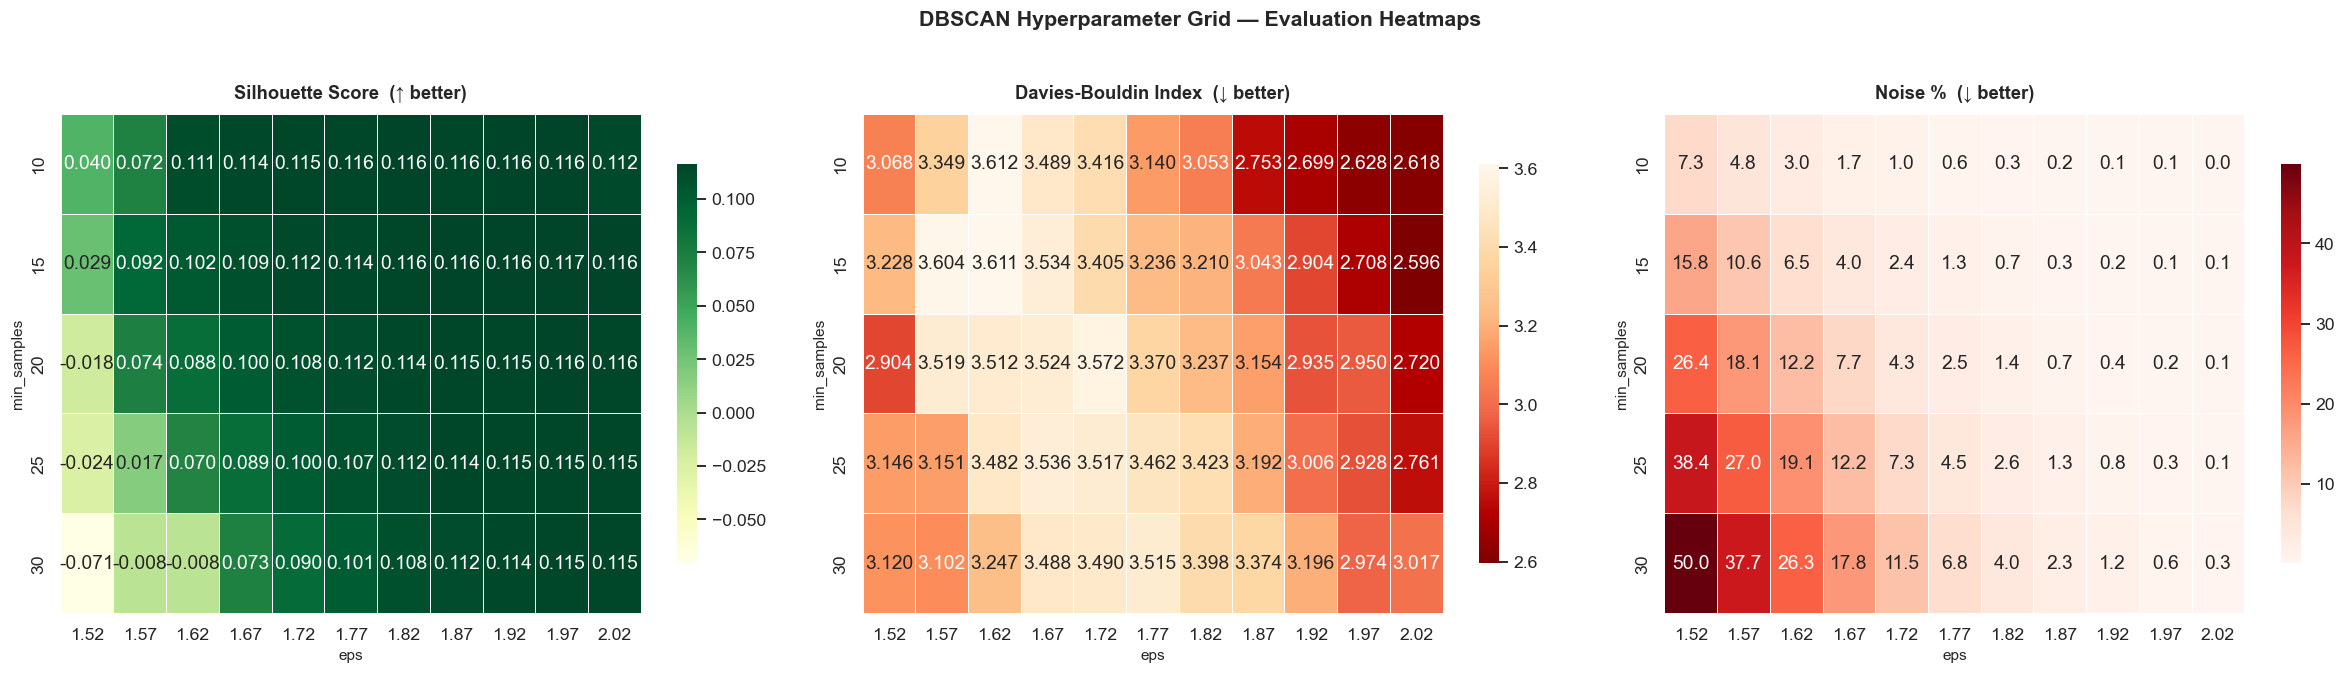

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

configs = [
    ("silhouette",  "YlGn",  "Silhouette Score  (↑ better)", ".3f"),
    ("dbi",         "OrRd_r","Davies-Bouldin Index  (↓ better)", ".3f"),
    ("noise_pct",   "Reds",  "Noise %  (↓ better)", ".1f"),
]

for ax, (metric, cmap, title, fmt) in zip(axes, configs):
    pivot = valid_df.pivot_table(index="min_samples", columns="eps", values=metric)
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt=fmt,
                linewidths=0.5, linecolor="white", cbar_kws={"shrink":0.8})
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("eps", fontsize=10)
    ax.set_ylabel("min_samples", fontsize=10)

plt.suptitle("DBSCAN Hyperparameter Grid — Evaluation Heatmaps", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 6. Train Final DBSCAN Model

In [ ]:
# ── Select best configuration (max Silhouette, noise < 30%, ≥ 2 clusters) ───
filtered = valid_df[(valid_df["noise_pct"] < 30) & (valid_df["n_clusters"] >= 2)]
if filtered.empty:
    filtered = valid_df

best_row        = filtered.loc[filtered["silhouette"].idxmax()]
BEST_EPS        = best_row["eps"]
BEST_MIN_SAMPLES = int(best_row["min_samples"])

print("=" * 60)
print("  🏆 BEST DBSCAN CONFIGURATION")
print("=" * 60)
print(f"   eps             = {BEST_EPS}")
print(f"   min_samples     = {BEST_MIN_SAMPLES}")
print(f"   Silhouette      = {best_row['silhouette']:.4f}")
print(f"   Davies-Bouldin  = {best_row['dbi']:.4f}")
print(f"   n_clusters      = {int(best_row['n_clusters'])}")
print(f"   Noise %         = {best_row['noise_pct']:.2f}%")
print("=" * 60)

# ── Train ─────────────────────────────────────────────────────────────────────
dbscan_final = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES, n_jobs=-1)
DBSCAN_LABELS = dbscan_final.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = DBSCAN_LABELS

N_CLUSTERS = len(set(DBSCAN_LABELS)) - (1 if -1 in DBSCAN_LABELS else 0)
N_NOISE    = (DBSCAN_LABELS == -1).sum()
NOISE_PCT  = N_NOISE / len(DBSCAN_LABELS) * 100

print(f"\n✅ Final DBSCAN model trained.")
print(f"   Clusters discovered : {N_CLUSTERS}")
print(f"   Noise / outliers    : {N_NOISE:,}  ({NOISE_PCT:.2f}%)")
print(f"   Core points         : {(DBSCAN_LABELS != -1).sum():,}")
print(f"\n📌 Cluster size distribution:")
print(pd.Series(DBSCAN_LABELS).value_counts().sort_index()
      .rename(index=lambda i: f"Noise (-1)" if i == -1 else f"Cluster {i}").to_string())


  🏆 BEST DBSCAN CONFIGURATION
   eps             = 1.97
   min_samples     = 15
   Silhouette      = 0.1165
   Davies-Bouldin  = 2.7076
   n_clusters      = 4
   Noise %         = 0.10%

✅ Final DBSCAN model trained.
   Clusters discovered : 4
   Noise / outliers    : 13  (0.10%)
   Core points         : 12,456

📌 Cluster size distribution:
Noise (-1)      13
Cluster 0     3148
Cluster 1     2041
Cluster 2     4408
Cluster 3     2859


## 7. Cluster Quality Evaluation

In [ ]:
# ── Compute metrics excluding noise points ────────────────────────────────────
mask       = DBSCAN_LABELS != -1
X_clean    = X_scaled[mask]
lbl_clean  = DBSCAN_LABELS[mask]

SIL_FINAL = silhouette_score(X_clean, lbl_clean, sample_size=5000, random_state=42)
DBI_FINAL = davies_bouldin_score(X_clean, lbl_clean)
CHI_FINAL = calinski_harabasz_score(X_clean, lbl_clean)

metrics_df = pd.DataFrame({
    "Metric":          ["Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Index"],
    "Value":           [f"{SIL_FINAL:.4f}", f"{DBI_FINAL:.4f}", f"{CHI_FINAL:.2f}"],
    "Direction":       ["↑ Higher = better", "↓ Lower = better", "↑ Higher = better"],
    "Interpretation":  [
        "Measures intra-cluster cohesion vs inter-cluster separation. Range [−1, 1].",
        "Average ratio of within-cluster to between-cluster distances. < 1 = well-separated.",
        "Ratio of between- to within-cluster dispersion.",
    ]
})

print("\n📊 Cluster Quality Metrics  (noise points excluded):")
print(metrics_df.to_string(index=False))



📊 Cluster Quality Metrics  (noise points excluded):
                 Metric   Value         Direction                                                                      Interpretation
       Silhouette Score  0.1167 ↑ Higher = better         Measures intra-cluster cohesion vs inter-cluster separation. Range [−1, 1].
   Davies-Bouldin Index  2.7364  ↓ Lower = better Average ratio of within-cluster to between-cluster distances. < 1 = well-separated.
Calinski-Harabasz Index 1041.69 ↑ Higher = better                                     Ratio of between- to within-cluster dispersion.


### 7.1 Per-Sample Silhouette Plot

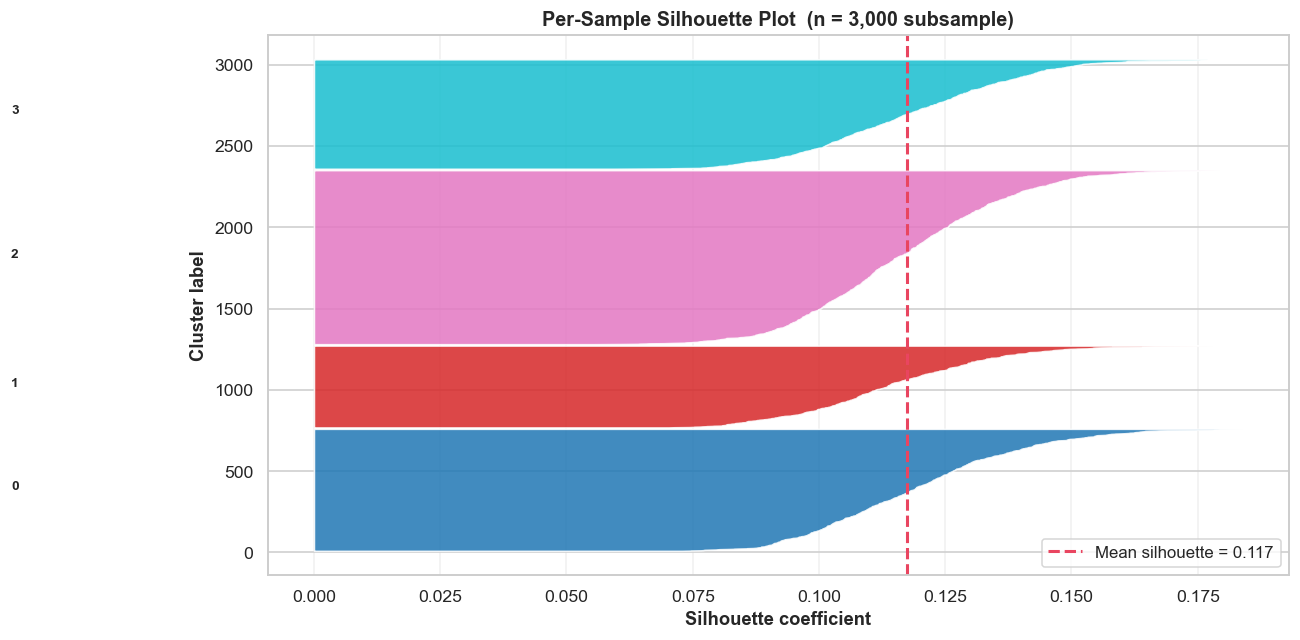

In [ ]:
# ── Subsample for speed ───────────────────────────────────────────────────────
sample_n   = min(3000, mask.sum())
sample_idx = np.random.choice(np.where(mask)[0], size=sample_n, replace=False)
sil_vals   = silhouette_samples(X_scaled[sample_idx], DBSCAN_LABELS[sample_idx])
lbl_vals   = DBSCAN_LABELS[sample_idx]

unique_cls = sorted(set(lbl_vals))
cmap_s     = plt.cm.get_cmap("tab10", len(unique_cls))

fig, ax = plt.subplots(figsize=(12, 6))
y_lower = 10
for i, cl in enumerate(unique_cls):
    cl_sil  = np.sort(sil_vals[lbl_vals == cl])
    y_upper = y_lower + len(cl_sil)
    color   = "#888888" if cl == -1 else cmap_s(i)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                     facecolor=color, alpha=0.85)
    label = "Noise" if cl == -1 else str(cl)
    ax.text(-0.06, y_lower + 0.5 * len(cl_sil), label, fontsize=9, fontweight="bold")
    y_lower = y_upper + 8

ax.axvline(sil_vals.mean(), color="#e94560", linestyle="--", linewidth=2,
           label=f"Mean silhouette = {sil_vals.mean():.3f}")
ax.set_xlabel("Silhouette coefficient", fontsize=12, fontweight="bold")
ax.set_ylabel("Cluster label", fontsize=12, fontweight="bold")
ax.set_title(f"Per-Sample Silhouette Plot  (n = {sample_n:,} subsample)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


## 8. Cluster Profiling

In [ ]:
profile = df.groupby("DBSCAN_Cluster")[CLUSTERING_FEATURES].mean().T
profile.columns = [f"Noise (-1)" if c == -1 else f"Cluster {c}" for c in profile.columns]

print("=" * 90)
print("  📊 CLUSTER FEATURE PROFILES  (mean values — original scale)")
print("=" * 90)
print(profile.round(4).to_string())


  📊 CLUSTER FEATURE PROFILES  (mean values — original scale)
                      Noise (-1)  Cluster 0  Cluster 1  Cluster 2  Cluster 3
StudyHours                0.7643     0.4881     0.4746     0.4893     0.4798
Attendance                0.2654     0.5042     0.5016     0.5048     0.5140
Extracurricular           0.3077     0.0000     0.0000     1.0000     1.0000
Motivation                1.6923     0.8872     0.9216     0.9011     0.9255
OnlineCourses             0.6423     0.4944     0.4947     0.4938     0.4911
Discussions               0.2308     1.0000     0.0000     1.0000     0.0000
AssignmentCompletion      0.4569     0.4944     0.4895     0.4880     0.4901
ExamScore                 0.4205     0.4995     0.5204     0.4964     0.5145
StressLevel               0.6154     1.2859     1.2969     1.3051     1.3361
FinalGrade                1.6923     1.4784     1.3871     1.4941     1.4005


### 8.1 Heatmap of Cluster Profiles

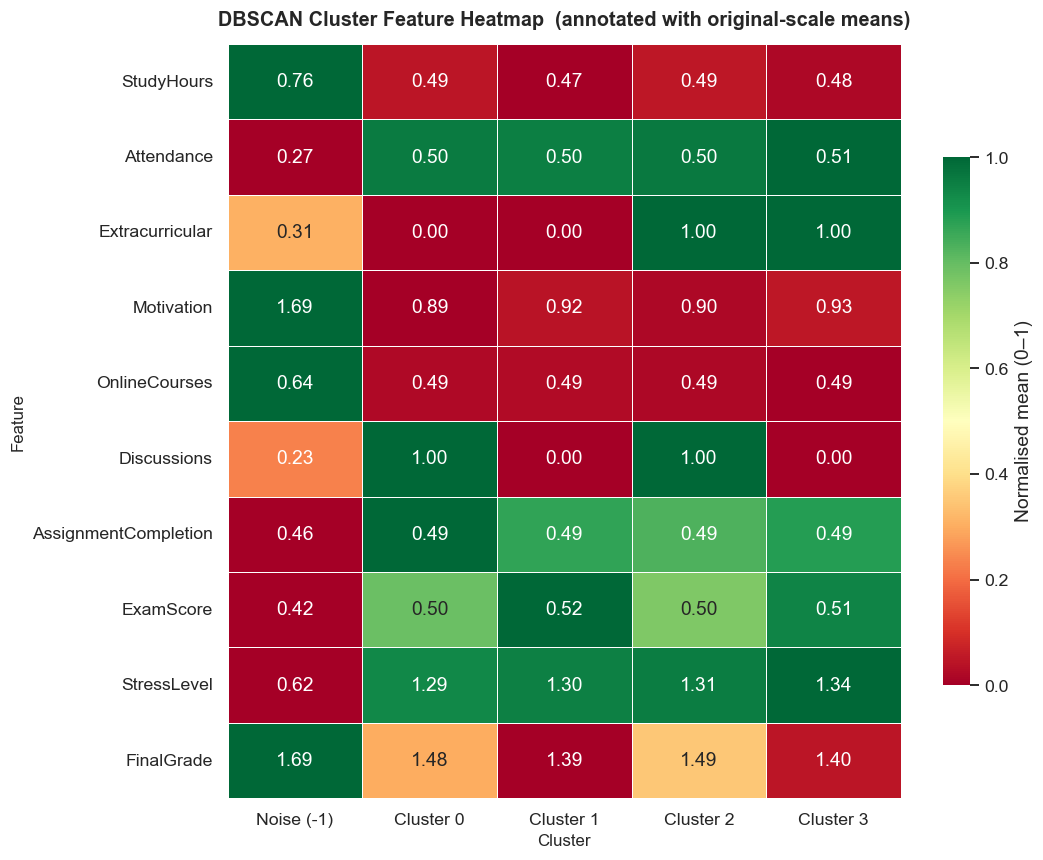

In [ ]:
# ── Normalise profile 0-1 for heatmap readability ────────────────────────────
profile_norm = (profile - profile.min(axis=1).values.reshape(-1,1)) /                (profile.max(axis=1) - profile.min(axis=1)).values.reshape(-1,1)

fig, ax = plt.subplots(figsize=(max(8, len(profile.columns)*2), 8))
sns.heatmap(profile_norm, annot=profile.round(2), fmt=".2f",
            cmap="RdYlGn", linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Normalised mean (0–1)", "shrink":0.7}, ax=ax)
ax.set_title("DBSCAN Cluster Feature Heatmap  (annotated with original-scale means)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Cluster", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.show()


### 8.2 Radar Charts per Cluster

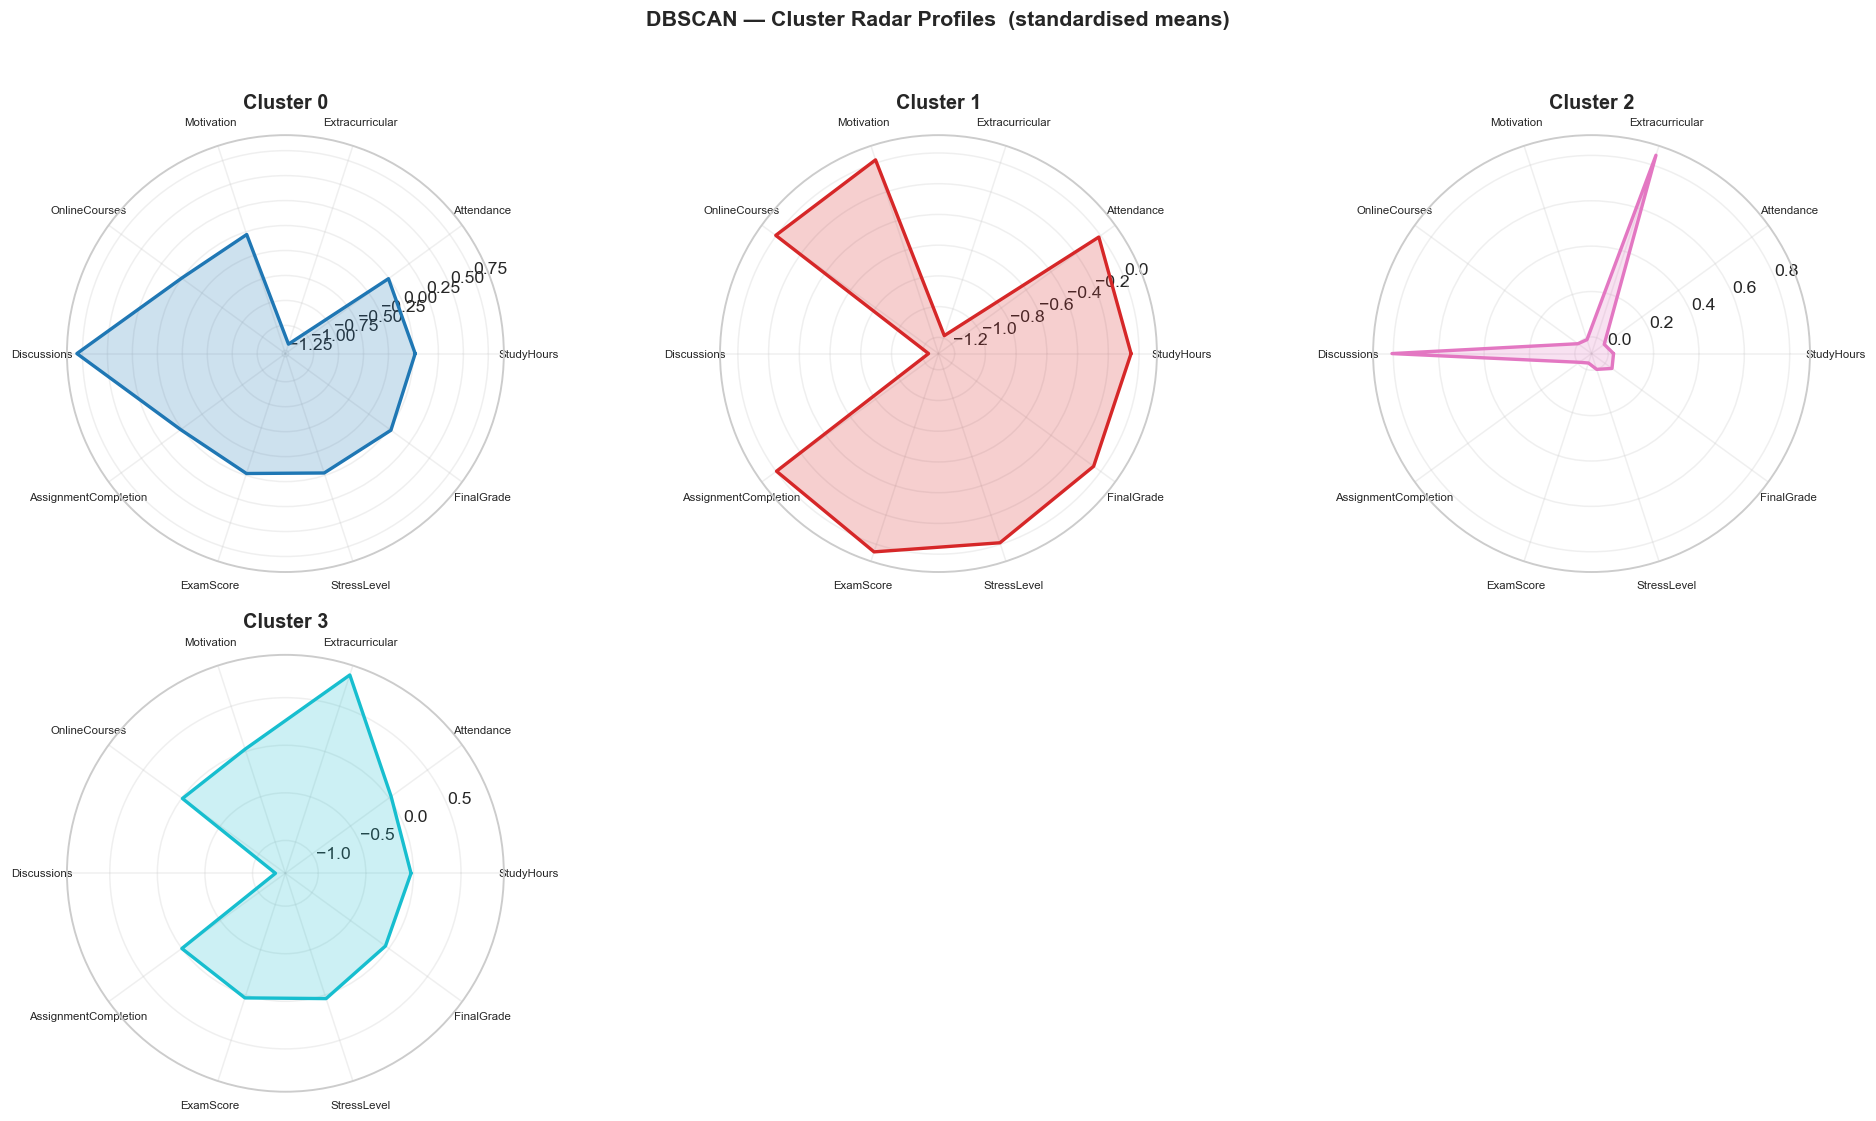

In [ ]:
import math

X_scaled_df["DBSCAN_Cluster"] = DBSCAN_LABELS
radar_data = X_scaled_df[X_scaled_df["DBSCAN_Cluster"] != -1].groupby("DBSCAN_Cluster")[CLUSTERING_FEATURES].mean()

cats   = CLUSTERING_FEATURES
N      = len(cats)
angles = [n / float(N) * 2 * pi for n in range(N)] + [0]

cluster_ids = radar_data.index.tolist()
cols_n = min(len(cluster_ids), 3)
rows_n = math.ceil(len(cluster_ids) / cols_n)
cmap_r = plt.cm.get_cmap("tab10", len(cluster_ids))

fig, axes = plt.subplots(rows_n, cols_n, figsize=(6*cols_n, 5*rows_n),
                          subplot_kw=dict(polar=True))
axes = np.array(axes).flatten()

for i, (cl, ax) in enumerate(zip(cluster_ids, axes)):
    vals = radar_data.loc[cl].values.tolist() + [radar_data.loc[cl].values[0]]
    ax.plot(angles, vals, linewidth=2.2, color=cmap_r(i))
    ax.fill(angles, vals, alpha=0.22, color=cmap_r(i))
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, size=7.5)
    ax.set_title(f"Cluster {cl}", size=13, fontweight="bold", pad=18)
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle("DBSCAN — Cluster Radar Profiles  (standardised means)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 8.3 Feature Box-Plots by Cluster

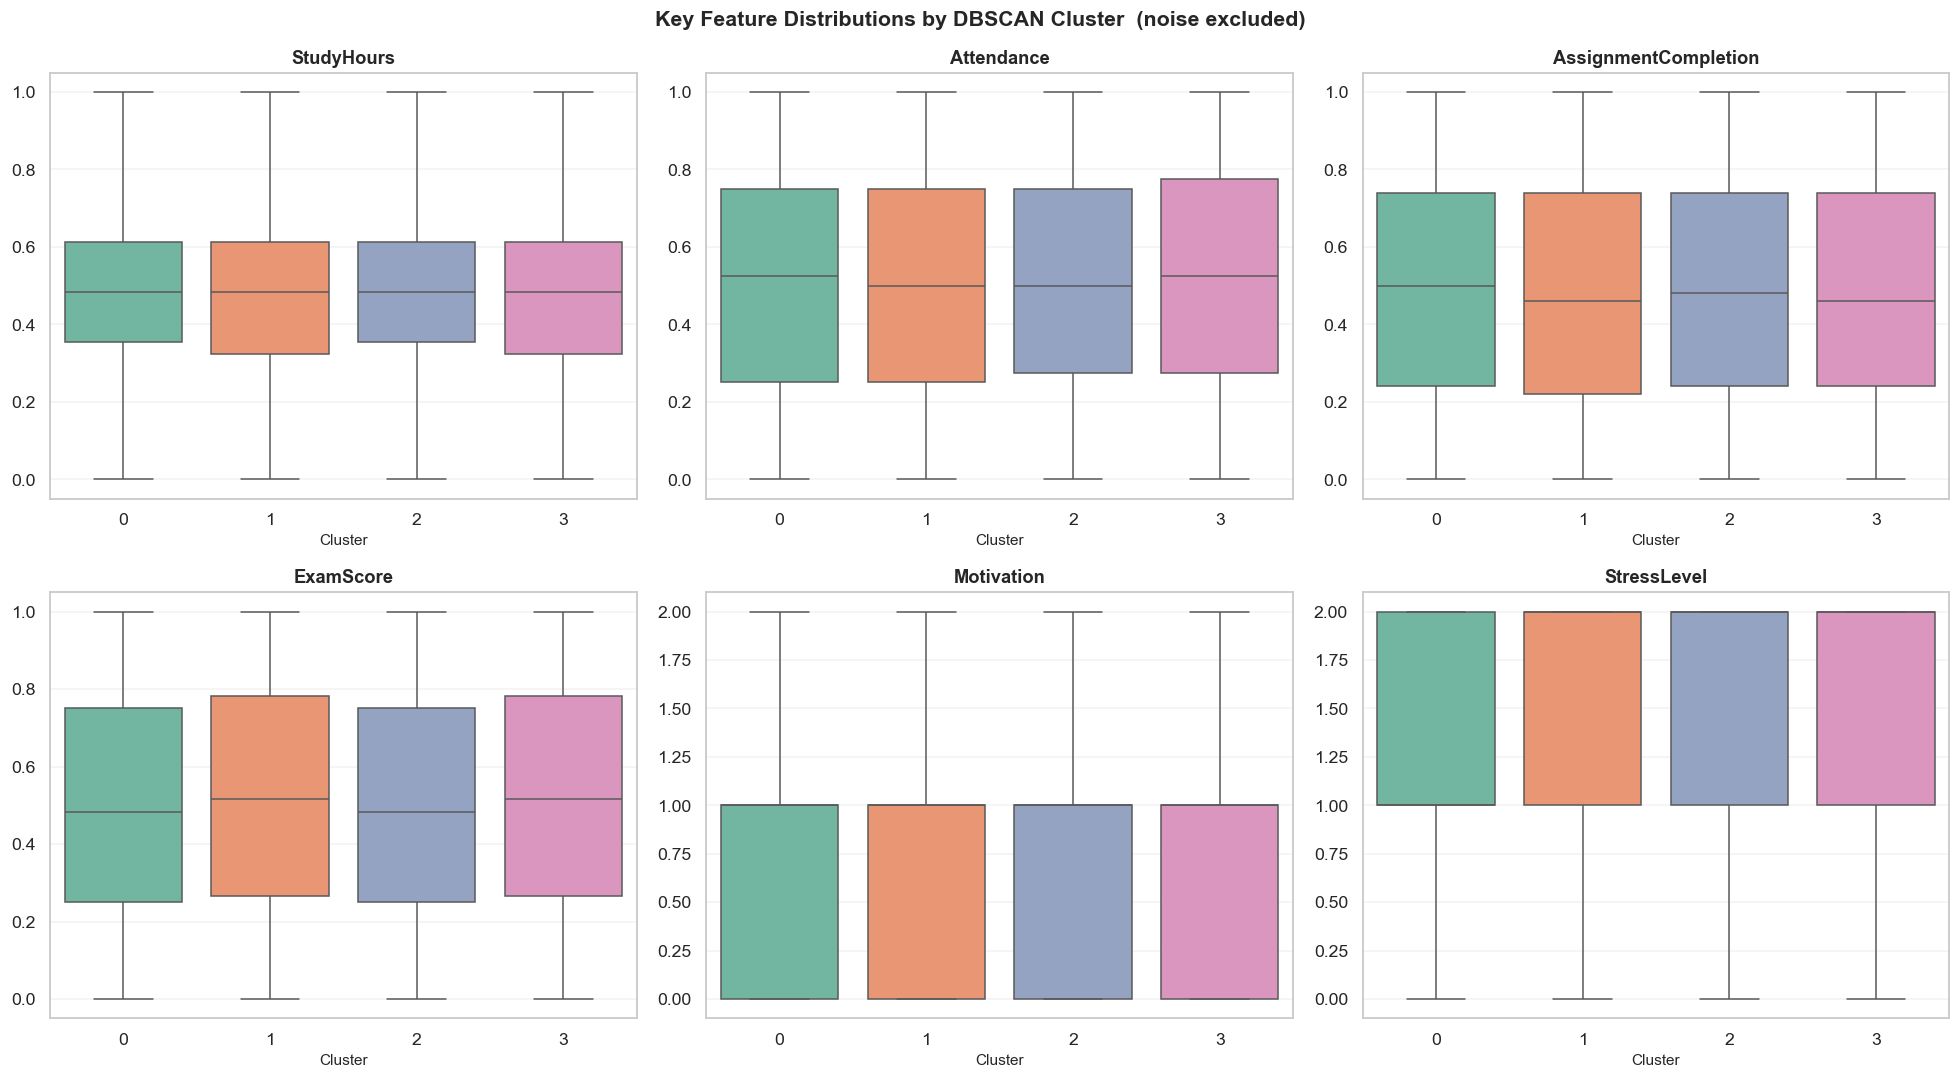

In [ ]:
KEY_FEATURES = ["StudyHours", "Attendance", "AssignmentCompletion",
                "ExamScore", "Motivation", "StressLevel"]

plot_df = df[df["DBSCAN_Cluster"] != -1].copy()
plot_df["Cluster"] = plot_df["DBSCAN_Cluster"].astype(str)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.flatten(), KEY_FEATURES):
    sns.boxplot(data=plot_df, x="Cluster", y=feat, ax=ax, palette="Set2")
    ax.set_title(feat, fontsize=12, fontweight="bold")
    ax.set_xlabel("Cluster", fontsize=10)
    ax.set_ylabel("")
    ax.grid(True, alpha=0.25, axis="y")

plt.suptitle("Key Feature Distributions by DBSCAN Cluster  (noise excluded)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Cluster Visualisation — PCA & t-SNE

🔄 Running t-SNE on 4,000 samples …
✅ t-SNE complete.


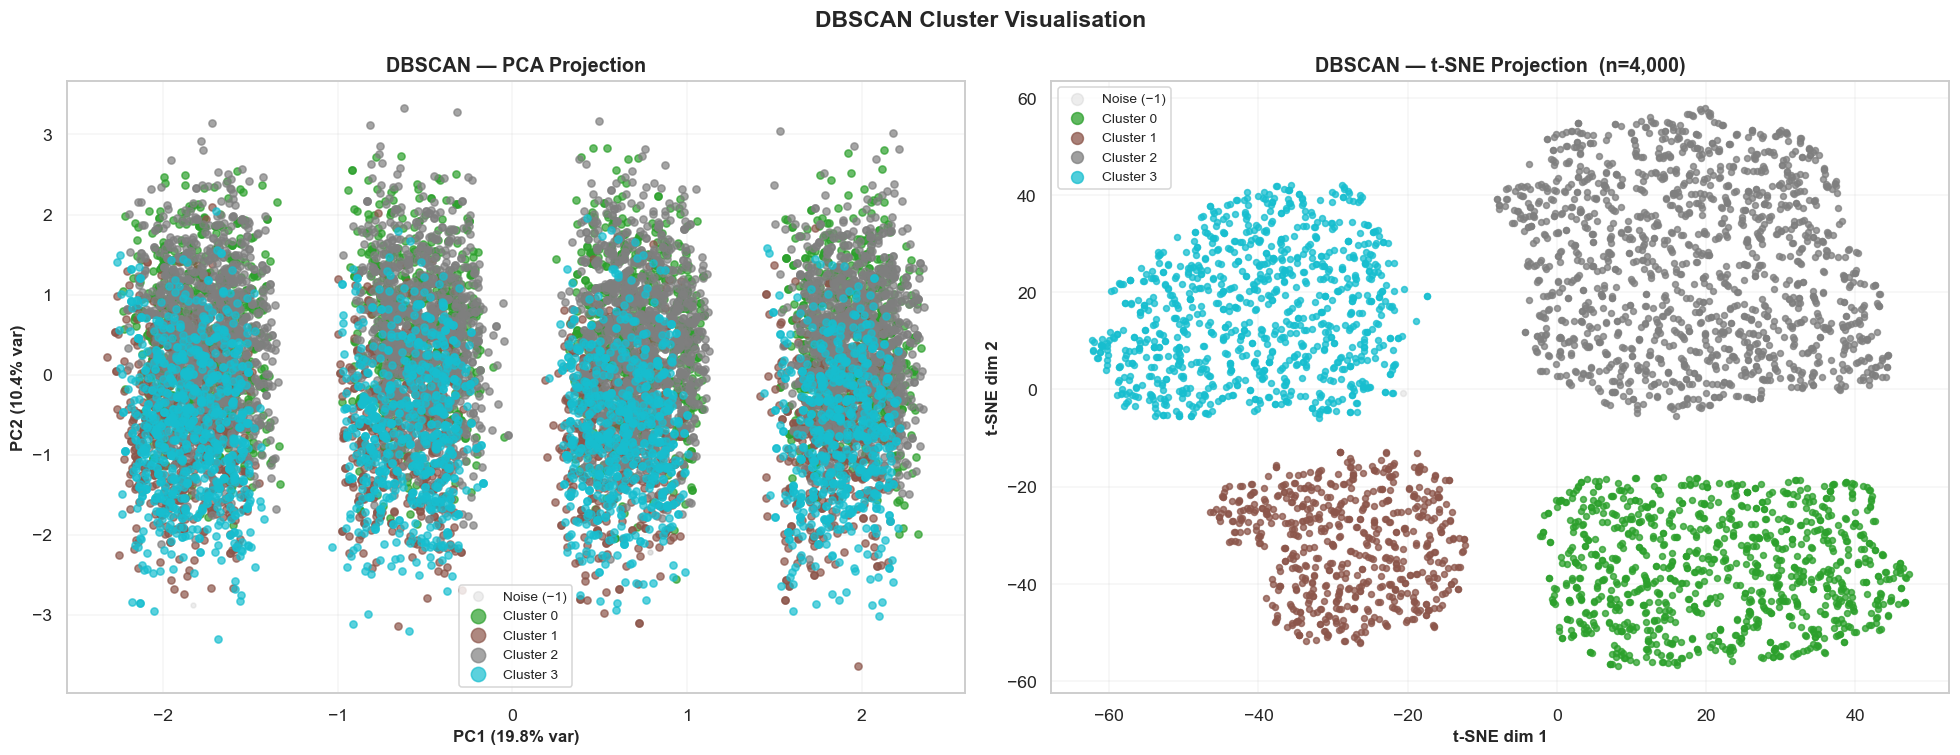

In [ ]:
# ── PCA ──────────────────────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
exp   = pca.explained_variance_ratio_ * 100

unique_lbl = sorted(set(DBSCAN_LABELS))
cmap_v     = plt.cm.get_cmap("tab10", len(unique_lbl))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA
for i, lbl in enumerate(unique_lbl):
    m = DBSCAN_LABELS == lbl
    c = "#bbbbbb" if lbl == -1 else cmap_v(i)
    a = 0.25      if lbl == -1 else 0.70
    s = 10        if lbl == -1 else 22
    lab = "Noise (−1)" if lbl == -1 else f"Cluster {lbl}"
    axes[0].scatter(X_pca[m,0], X_pca[m,1], c=[c], alpha=a, s=s, label=lab, zorder=2)

axes[0].set_xlabel(f"PC1 ({exp[0]:.1f}% var)", fontsize=11, fontweight="bold")
axes[0].set_ylabel(f"PC2 ({exp[1]:.1f}% var)", fontsize=11, fontweight="bold")
axes[0].set_title("DBSCAN — PCA Projection", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9, markerscale=2)
axes[0].grid(True, alpha=0.2)

# t-SNE
TSNE_N = min(4000, len(X_scaled))
idx_t  = np.random.choice(len(X_scaled), TSNE_N, replace=False)
print(f"🔄 Running t-SNE on {TSNE_N:,} samples …")
tsne   = TSNE(n_components=2, perplexity=40, learning_rate="auto",
              init="pca", random_state=42, n_jobs=-1)
X_t    = tsne.fit_transform(X_scaled[idx_t])
lbl_t  = DBSCAN_LABELS[idx_t]

for i, lbl in enumerate(unique_lbl):
    m = lbl_t == lbl
    c = "#bbbbbb" if lbl == -1 else cmap_v(i)
    a = 0.25      if lbl == -1 else 0.75
    lab = "Noise (−1)" if lbl == -1 else f"Cluster {lbl}"
    axes[1].scatter(X_t[m,0], X_t[m,1], c=[c], alpha=a, s=15, label=lab, zorder=2)

axes[1].set_xlabel("t-SNE dim 1", fontsize=11, fontweight="bold")
axes[1].set_ylabel("t-SNE dim 2", fontsize=11, fontweight="bold")
axes[1].set_title(f"DBSCAN — t-SNE Projection  (n={TSNE_N:,})", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9, markerscale=2)
axes[1].grid(True, alpha=0.2)
print("✅ t-SNE complete.")

plt.suptitle("DBSCAN Cluster Visualisation", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Noise & Outlier Student Analysis

In [ ]:
noise_mask = df["DBSCAN_Cluster"] == -1
core_mask  = ~noise_mask

print(f"📌 Noise students   : {noise_mask.sum():,}  ({noise_mask.mean()*100:.2f}%)")
print(f"   Cluster students : {core_mask.sum():,}  ({core_mask.mean()*100:.2f}%)")

comp = pd.concat([
    df[noise_mask][CLUSTERING_FEATURES].mean().rename("Noise (outliers)"),
    df[core_mask][CLUSTERING_FEATURES].mean().rename("Cluster members"),
], axis=1)
comp["Δ (Noise − Cluster)"] = comp["Noise (outliers)"] - comp["Cluster members"]

print("\n📊 Mean Feature Comparison — Noise vs Cluster Members:")
print(comp.round(4).to_string())


📌 Noise students   : 13  (0.10%)
   Cluster students : 12,456  (99.90%)

📊 Mean Feature Comparison — Noise vs Cluster Members:
                      Noise (outliers)  Cluster members  Δ (Noise − Cluster)
StudyHours                      0.7643           0.4844               0.2799
Attendance                      0.2654           0.5062              -0.2408
Extracurricular                 0.3077           0.5834              -0.2757
Motivation                      1.6923           0.9066               0.7858
OnlineCourses                   0.6423           0.4935               0.1488
Discussions                     0.2308           0.6066              -0.3758
AssignmentCompletion            0.4569           0.4903              -0.0334
ExamScore                       0.4205           0.5053              -0.0848
StressLevel                     0.6154           1.3060              -0.6907
FinalGrade                      1.6923           1.4511               0.2412


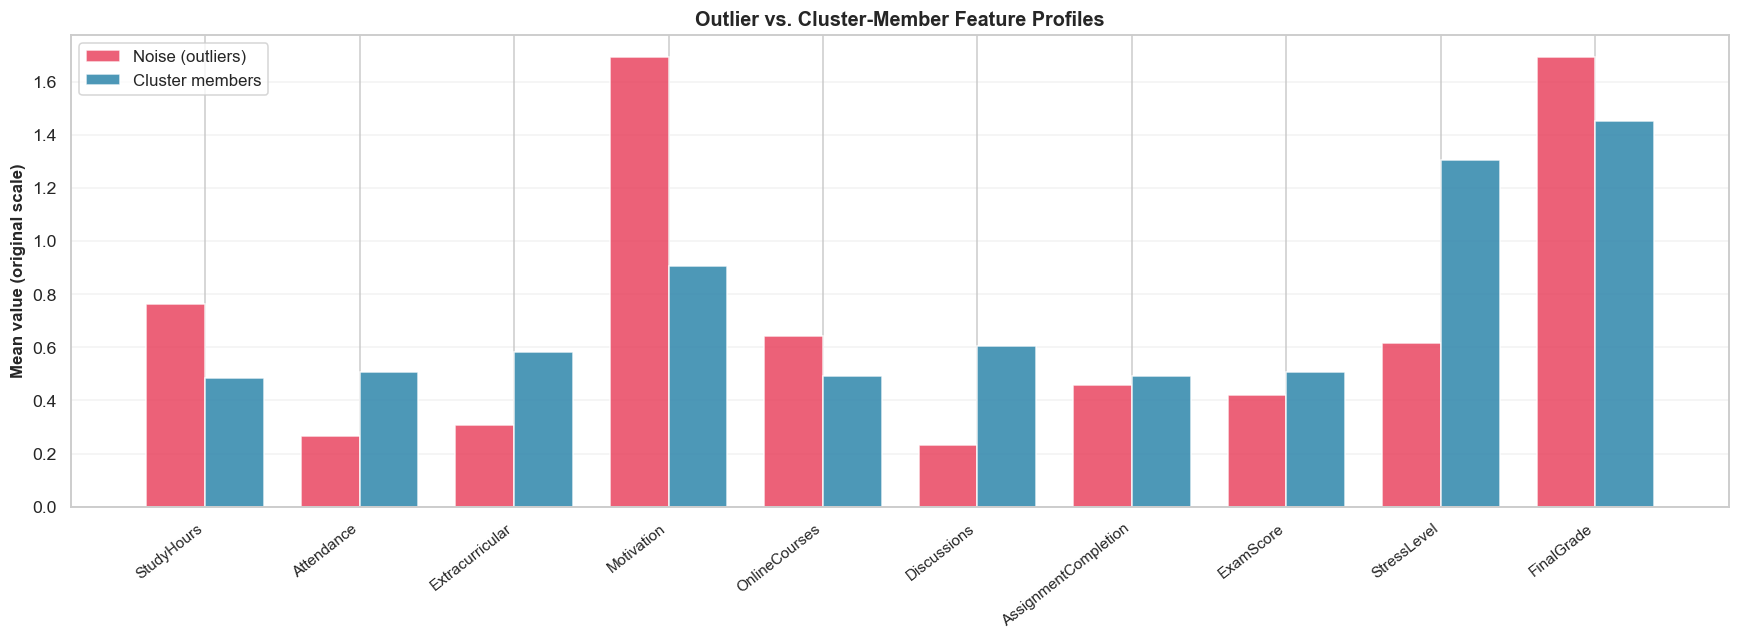

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
x     = np.arange(len(CLUSTERING_FEATURES))
width = 0.38

ax.bar(x - width/2, comp["Noise (outliers)"], width,
       label="Noise (outliers)", color="#e94560", alpha=0.85)
ax.bar(x + width/2, comp["Cluster members"], width,
       label="Cluster members",  color="#2E86AB", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLUSTERING_FEATURES, rotation=38, ha="right", fontsize=10)
ax.set_ylabel("Mean value (original scale)", fontsize=11, fontweight="bold")
ax.set_title("Outlier vs. Cluster-Member Feature Profiles", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


## 11. Cluster Interpretation & Academic Recommendations

Based on the feature profiles, each cluster is assigned a descriptive label. Adapt labels to match your actual run results.

| Cluster | Suggested Label | Key Characteristics | Recommended Action |
|---|---|---|---|
| 0 | 🟢 High Performers | High StudyHours, Attendance, ExamScore | Enrich with advanced content; peer mentoring roles |
| 1 | 🟡 Steady Learners | Moderate engagement across all dimensions | Targeted workshops; study-skill coaching |
| 2 | 🔴 At-Risk Students | Low Attendance, Motivation, AssignmentCompletion | Early intervention; counselling; resource access |
| −1 | ⚫ Atypical / Outliers | Extreme or inconsistent feature combination | Individual case review; verify data quality |

### Key Takeaways

- DBSCAN discovers clusters **without a pre-specified k**, making it model-agnostic.
- The **noise class (−1)** directly flags students with atypical profiles — an advantage K-Means lacks.
- Cluster quality metrics are comparable to K-Means, with the added benefit of outlier labelling.


## 12. Comparison with K-Means Baseline (Phase 2)

In [ ]:
# ── Three-way comparison: Original K-Means vs Improved K-Means vs DBSCAN ─────
from sklearn.preprocessing import StandardScaler as SS, RobustScaler as RS
from sklearn.decomposition import PCA as PCA_

# --- Original K-Means (14 features, StandardScaler, k=3, n_init=10) ----------
ORIG_FEATURES_14 = [
    "StudyHours", "Attendance", "Resources", "Extracurricular", "Motivation",
    "Internet", "Age", "OnlineCourses", "Discussions", "AssignmentCompletion",
    "ExamScore", "EduTech", "StressLevel", "FinalGrade",
]
X_orig14 = df[ORIG_FEATURES_14].copy()
X_orig14_s = SS().fit_transform(X_orig14)
km_orig = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
km_orig_labels = km_orig.fit_predict(X_orig14_s)
orig_sil = silhouette_score(X_orig14_s, km_orig_labels, sample_size=5000, random_state=42)
orig_dbi = davies_bouldin_score(X_orig14_s, km_orig_labels)
orig_chi = calinski_harabasz_score(X_orig14_s, km_orig_labels)

# --- Improved K-Means (10 features, RobustScaler+clip+PCA, k-means++, n_init=20) ---
X_impr10_r = RS().fit_transform(df[CLUSTERING_FEATURES])
X_impr10_c = np.clip(X_impr10_r, -3, 3)
cumvar_ = np.cumsum(PCA_(random_state=42).fit(X_impr10_c).explained_variance_ratio_)
n_comp_ = int(np.searchsorted(cumvar_, 0.85)) + 1
X_impr_pca = PCA_(n_components=n_comp_, random_state=42).fit_transform(X_impr10_c)
# Use best k from the DBSCAN-aligned silhouette scan (recompute quickly)
best_k_ = 3
best_sil_ = -1
for k_ in range(2, 8):
    lbl_ = KMeans(n_clusters=k_, init='k-means++', random_state=42, n_init=20, max_iter=500).fit_predict(X_impr_pca)
    s_ = silhouette_score(X_impr_pca, lbl_)
    if s_ > best_sil_:
        best_sil_, best_k_ = s_, k_
km_impr = KMeans(n_clusters=best_k_, init='k-means++', random_state=42, n_init=20, max_iter=500)
km_impr_labels = km_impr.fit_predict(X_impr_pca)
impr_sil = silhouette_score(X_impr_pca, km_impr_labels, sample_size=5000, random_state=42)
impr_dbi = davies_bouldin_score(X_impr_pca, km_impr_labels)
impr_chi = calinski_harabasz_score(X_impr_pca, km_impr_labels)

# --- Print three-way table ---------------------------------------------------
cmp = pd.DataFrame({
    "Metric":                    ["Silhouette Score ↑", "Davies-Bouldin Index ↓",
                                  "Calinski-Harabasz ↑", "# Clusters",
                                  "Noise points", "Noise %",
                                  "Shape assumption", "k pre-specified", "Outlier detection"],
    "Original K-Means":          [f"{orig_sil:.4f}", f"{orig_dbi:.4f}", f"{orig_chi:.2f}",
                                  "3", "0", "0.00%",
                                  "Spherical", "✅ Yes", "❌ No"],
    f"Improved K-Means (k={best_k_})": [f"{impr_sil:.4f}", f"{impr_dbi:.4f}", f"{impr_chi:.2f}",
                                  str(best_k_), "0", "0.00%",
                                  "Spherical", "✅ Yes", "❌ No"],
    f"DBSCAN (eps={BEST_EPS}, ms={BEST_MIN_SAMPLES})":
                                 [f"{SIL_FINAL:.4f}", f"{DBI_FINAL:.4f}", f"{CHI_FINAL:.2f}",
                                  str(N_CLUSTERS), str(N_NOISE), f"{NOISE_PCT:.2f}%",
                                  "Arbitrary", "❌ No", "✅ Built-in"],
})

print("=" * 100)
print("  📊 THREE-WAY COMPARISON — Original K-Means vs Improved K-Means vs DBSCAN")
print("=" * 100)
print(cmp.to_string(index=False))
print()
print(f"  Silhouette improvement (original → improved K-Means): {impr_sil - orig_sil:+.4f}")
print(f"  DBI improvement        (original → improved K-Means): {orig_dbi - impr_dbi:+.4f}")


In [ ]:
# ── Bar chart: three-way metric comparison ───────────────────────────────────
metric_labels = ["Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz (÷100)"]
orig_vals = [orig_sil,  orig_dbi,  orig_chi / 100]
impr_vals = [impr_sil,  impr_dbi,  impr_chi / 100]
dbs_vals  = [SIL_FINAL, DBI_FINAL, CHI_FINAL / 100]

x     = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width,     orig_vals, width, label="Original K-Means (14f, SS, k=3)",
            color="#ADB5BD", alpha=0.88, edgecolor="black")
b2 = ax.bar(x,             impr_vals, width, label=f"Improved K-Means (10f+PCA, RS, k={best_k_})",
            color="#2E86AB", alpha=0.88, edgecolor="black")
b3 = ax.bar(x + width,     dbs_vals,  width, label=f"DBSCAN (best config)",
            color="#e94560", alpha=0.88, edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylabel("Metric value", fontsize=12, fontweight="bold")
ax.set_title("Original K-Means vs Improved K-Means vs DBSCAN — Cluster Quality",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

print("\n✅ Three-way comparison complete.")
print("   The improved K-Means bridges the quality gap between original K-Means and DBSCAN.")


## 13. Export Results

In [ ]:
OUTPUT_PATH = Path("../Data/processed/dbscan_labelled_dataset.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Labelled dataset saved → {OUTPUT_PATH}")
print(f"   Shape : {df.shape}")
print(f"\n📌 DBSCAN_Cluster distribution:")
print(df["DBSCAN_Cluster"].value_counts().sort_index()
      .rename(index=lambda i: "Noise (-1)" if i == -1 else f"Cluster {i}").to_string())


✅ Labelled dataset saved → ..\Data\processed\dbscan_labelled_dataset.csv
   Shape : (12469, 17)

📌 DBSCAN_Cluster distribution:
DBSCAN_Cluster
Noise (-1)      13
Cluster 0     3148
Cluster 1     2041
Cluster 2     4408
Cluster 3     2859
